***Постановка задачи***

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.

Необходимо разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

    Нужно промаркировать уровень финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».
    Нужно собрать данные по клиентам по следующим группам:
     
        -Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
        -Признаки, которые описывают продуктовое поведение покупателя. Например, какие товары покупает и как часто.
        -Признаки, которые описывают покупательское поведение клиента. Например, сколько тратил в магазине.
        -Признаки, которые описывают поведение покупателя на сайте. Например, как много страниц просматривает и сколько времени проводит на сайте.

Входные признаки можно объединить в четыре группы: коммуникация с клиентом, продуктовое поведение, поведение на сайте и финансовое поведение.

    Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
    В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
    Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.



Задачу предстоит решить в два этапа:

   - Разработать модель, которая предскажет вероятность снижения покупательской активности.
   - Выделить сегмент покупателей, проанализировать его и предложить, как увеличить его покупательскую активность. Будем использовать данные моделирования, данные о прибыли покупателей и исходные данные (если понадобятся).

**Шаг 1. Загрузка данных**

In [1]:
from sklearn.datasets import make_classification
from phik import phik_matrix
import seaborn as sns
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# загружаем функцию для работы с метриками
from sklearn.metrics import make_scorer, recall_score

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# загружаем нужные модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


In [2]:
market = pd.read_csv('market_file.csv')

In [3]:
market_money = pd.read_csv('market_money.csv')

In [4]:
market_time = pd.read_csv('market_time.csv')

In [5]:
money = pd.read_csv('money.csv',  sep=';', decimal=',')

In [6]:
market.head(10)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


In [7]:
market_money.head(10)

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4


In [8]:
market_time.head(10)

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдцщий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдцщий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдцщий_месяц,8


In [9]:
money.head(10)

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21
5,215353,3.95
6,215354,3.62
7,215355,5.26
8,215356,4.93
9,215357,4.66


***Промежуточный вывод по Шагу 1: видим, что данные в таблицах соответствуют описанию***

**Шаг 2. Предобработка данных**

Проверим данные на пропуски

In [10]:
market.isna().sum()

id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

In [11]:
market_money.isna().sum()

id         0
Период     0
Выручка    0
dtype: int64

In [12]:
market_time.isna().sum()

id        0
Период    0
минут     0
dtype: int64

In [13]:
money.isna().sum()

id         0
Прибыль    0
dtype: int64

Пропуски в данных отсутствуют

Теперь проверим данные на полные дубликаты

In [14]:
market.duplicated().sum()

0

In [15]:
market_money.duplicated().sum()

0

In [16]:
market_time.duplicated().sum()

0

In [17]:
money.duplicated().sum()

0

Видим, что дубликаты отсутствуют

Теперь приведем названия стоблцов к snake_case.

In [18]:
market.columns

Index(['id', 'Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
       'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Популярная_категория',
       'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит'],
      dtype='object')

Видим, что названия всех столбцов наичнаются с заглавной буквы, также в наименованиях столбов иногда встречаются пробелы вместо нижнего подчеркивания, напишем цикл для соответствующих замен

In [19]:
market.columns = [
    col.lower().replace(' ', '_') for col in market.columns]

In [20]:
market.columns

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'],
      dtype='object')

Видим, что названия преобразованы, сделаем то же для остальных датасетов 

In [21]:
market_money.columns = [
    col.lower() for col in market_money.columns]

In [22]:
market_time.columns = [
    col.lower() for col in market_time.columns]

In [23]:
money.columns = [
    col.lower() for col in money.columns]

Теперь посмотрим на уникальные значения категориальных столбцов, чтобы устранить некорректные значения (при наличии)

In [24]:
market['покупательская_активность'].unique()

array(['Снизилась', 'Прежний уровень'], dtype=object)

In [25]:
market['тип_сервиса'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

In [26]:
market.loc[market['тип_сервиса'] == 'стандартт', 'тип_сервиса'] = 'стандарт'

In [27]:
market['разрешить_сообщать'].unique()

array(['да', 'нет'], dtype=object)

In [28]:
market['популярная_категория'].unique()

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксесуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

In [29]:
market_money['период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [30]:
market_money['период'].value_counts()

период
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

In [31]:
market_time['период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [32]:
market_time.loc[market_time['период'] == 'предыдцщий_месяц', 'период'] = 'предыдущий_месяц'

In [33]:
market_time['период'].value_counts()

период
текущий_месяц       1300
предыдущий_месяц    1300
Name: count, dtype: int64

Видим, что датасет market_money содержит данные за три месяца, а датасет market_time - за два.

In [34]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   период   3900 non-null   object 
 2   выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [35]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [36]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


In [37]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

Типы данных столбцов соответствуют содержанию столбцов.

***Промежуточный вывод по Шагу 2: пропуски в датасетах отсутствовали, полные дубликаты отсутствовали, мы привели к snake_case названия столбцов, устранили несколько технических ошибок в значениях столбцов***

**Шаг 3. Исследовательский анализ данных**

Посмотрим на статистические данные датасета market

In [38]:
market.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.0,215672.75,215997.50,216322.25,216647.00
маркет_актив_6_мес,1300.0,4.253769,1.014814,0.9,3.70,4.20,4.90,6.60
маркет_актив_тек_мес,1300.0,4.011538,0.696868,3.0,4.00,4.00,4.00,5.00
длительность,1300.0,601.898462,249.856289,110.0,405.50,606.00,806.00,1079.00
акционные_покупки,1300.0,0.319808,0.249843,0.0,0.17,0.24,0.30,0.99
средний_просмотр_категорий_за_визит,1300.0,3.270000,1.355350,1.0,2.00,3.00,4.00,6.00
неоплаченные_продукты_штук_квартал,1300.0,2.840000,1.971451,0.0,1.00,3.00,4.00,10.00
ошибка_сервиса,1300.0,4.185385,1.955298,0.0,3.00,4.00,6.00,9.00
страниц_за_визит,1300.0,8.176923,3.978126,1.0,5.00,8.00,11.00,20.00


Среднее и медиана столбца "длительность" близки, что может говорить о симметричности распределения. В остальном каких-то особенностей не видно.

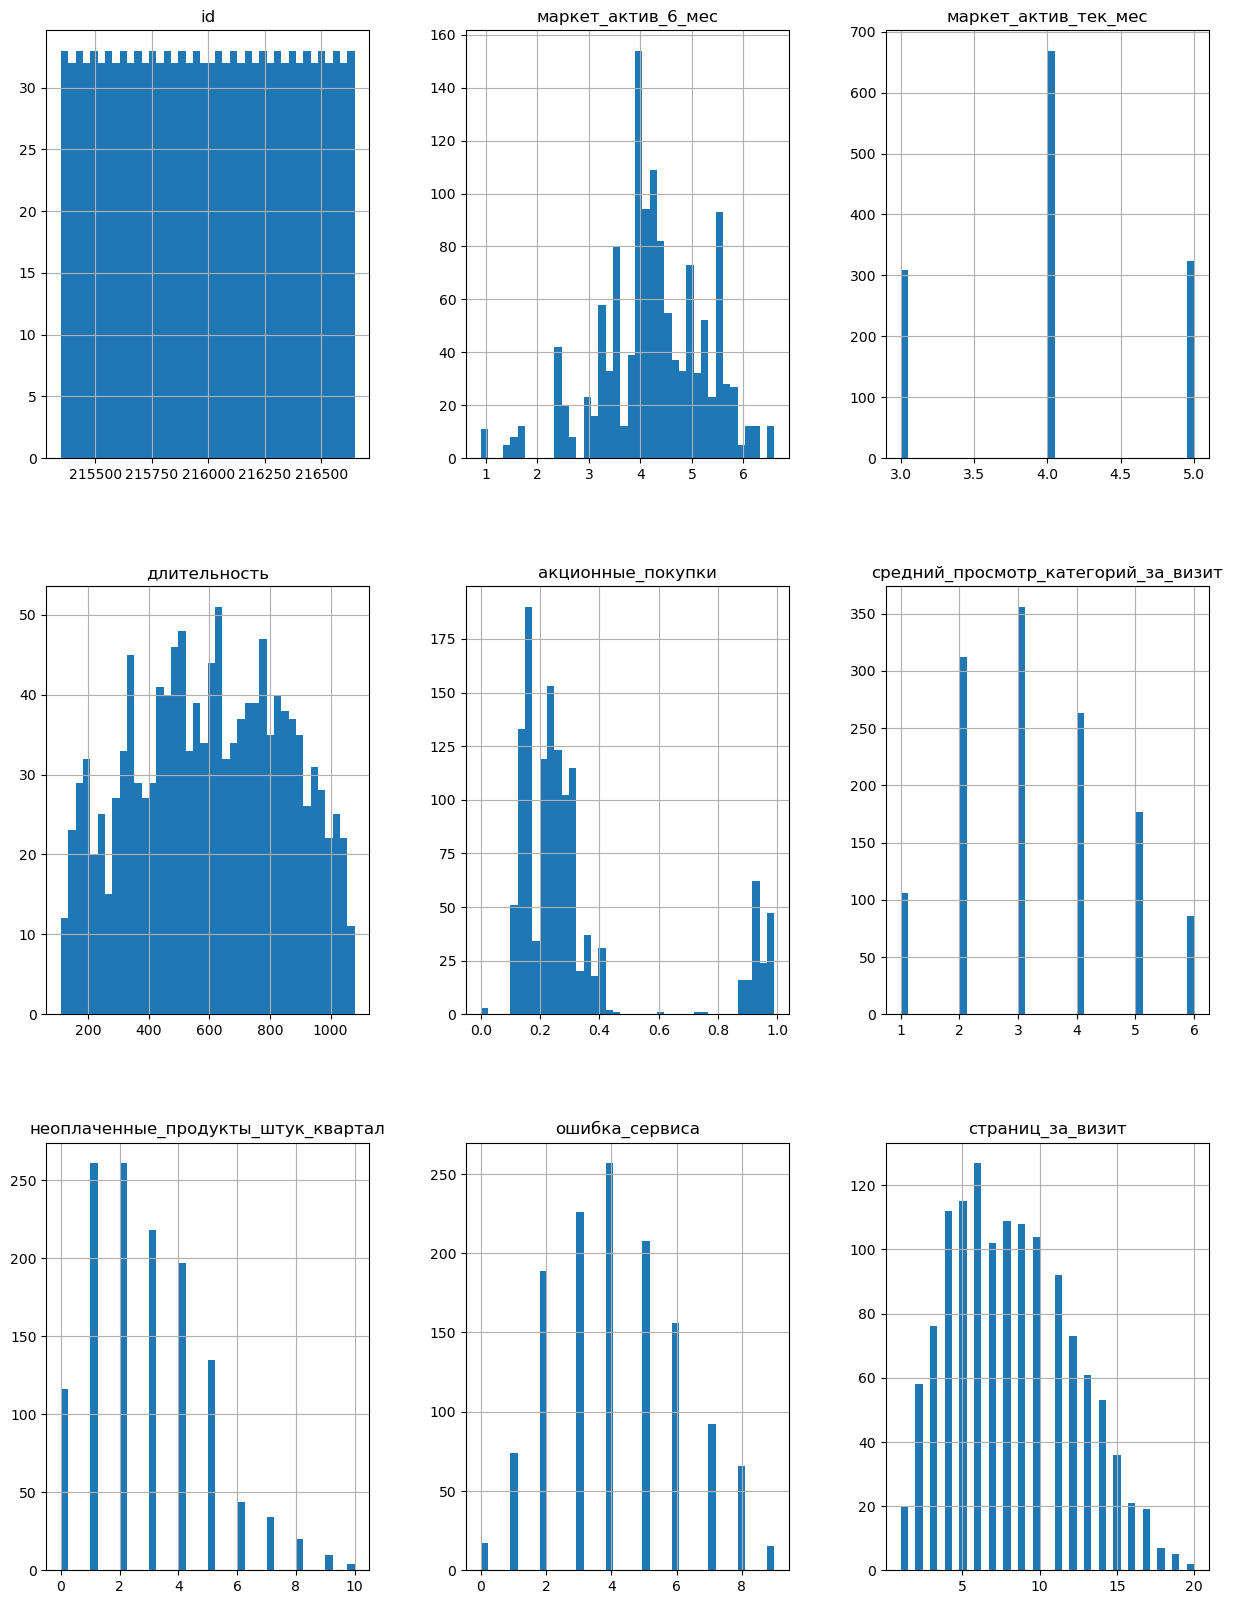

In [39]:
market.hist(figsize=(15, 20), bins = 40);

Видим дискретные распределения по столбцам "маркет_актив_тек_мес", "средний_просмотр_категорий_за_визит", "неоплаченные_продукты_штук_квартал", "ошибка_сервиса", "страниц_за_визит".

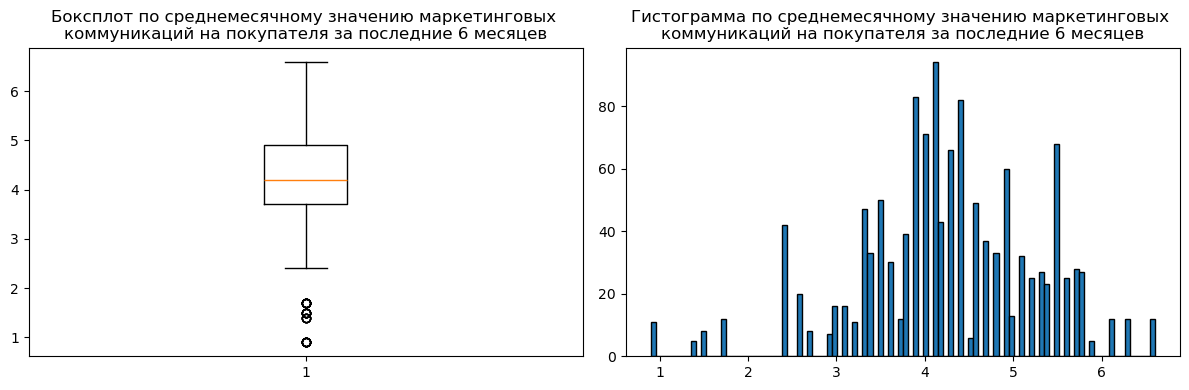

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64

In [40]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['маркет_актив_6_мес'])
axes[0].set_title('Боксплот по среднемесячному значению маркетинговых \nкоммуникаций на покупателя за последние 6 месяцев')

# Второй график — гистограмма
axes[1].hist(market['маркет_актив_6_мес'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по среднемесячному значению маркетинговых \nкоммуникаций на покупателя за последние 6 месяцев')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['маркет_актив_6_мес'].describe()

Видим небольшой хвост слева, который боксплот считает выбросами. Кроме того, хотя распределение и имеет колоколообразную форму, мы видим наличие нескольких пиков как слева, так и справа, что может говорить либо о многомодальном распределении, либо о сложной структуре данных, а не классической нормальной форме. 

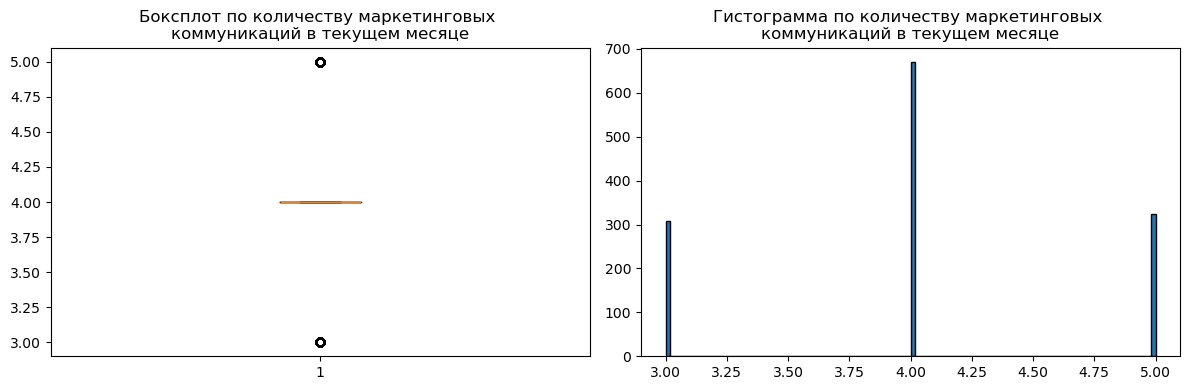

count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: маркет_актив_тек_мес, dtype: float64

In [41]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['маркет_актив_тек_мес'])
axes[0].set_title('Боксплот по количеству маркетинговых \nкоммуникаций в текущем месяце')

# Второй график — гистограмма
axes[1].hist(market['маркет_актив_тек_мес'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по количеству маркетинговых \nкоммуникаций в текущем месяце')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['маркет_актив_тек_мес'].describe()

Дискретное распределение. В распределении всего лишь три значения: 3, 4 и 5. Такой выборки недостаточно, чтобы сказать что-то определенное по распределению. Использование боксплота, гистограммы и метода describe в данном случае малоинформативно.

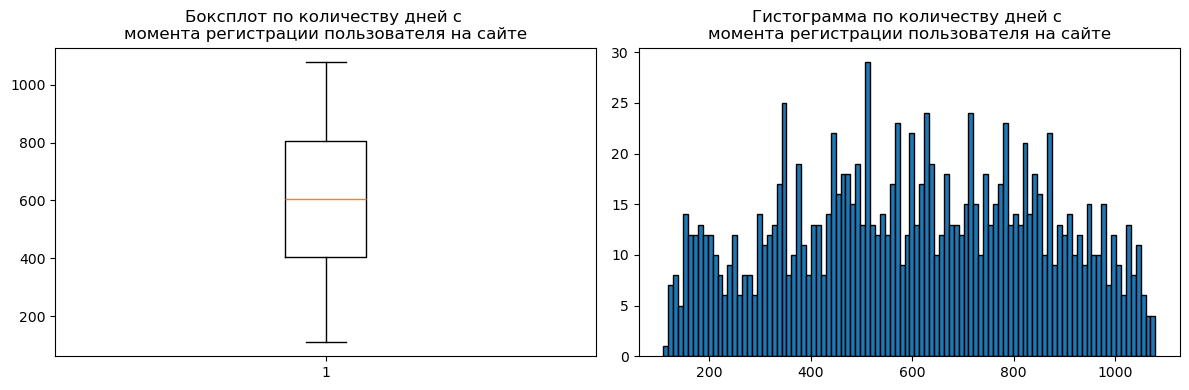

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64

In [42]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['длительность'])
axes[0].set_title('Боксплот по количеству дней с \nмомента регистрации пользователя на сайте')

# Второй график — гистограмма
axes[1].hist(market['длительность'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по количеству дней с \nмомента регистрации пользователя на сайте')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['длительность'].describe()

Данные распределены нормально.

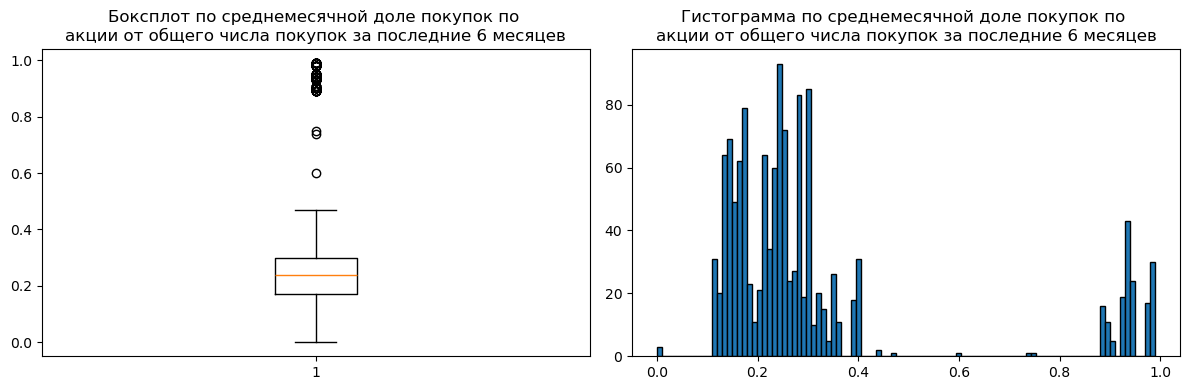

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64

In [43]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['акционные_покупки'])
axes[0].set_title('Боксплот по среднемесячной доле покупок по \nакции от общего числа покупок за последние 6 месяцев')

# Второй график — гистограмма
axes[1].hist(market['акционные_покупки'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по среднемесячной доле покупок по \nакции от общего числа покупок за последние 6 месяцев')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['акционные_покупки'].describe()

Боксплот относит значения, которые больше или равны 0.6 к выбросам. Визуально есть ощущение, что данные составляют два сегмента: с 0.1 до 0.4  и с 0.9 до 0.99. Данные не распределены нормально.

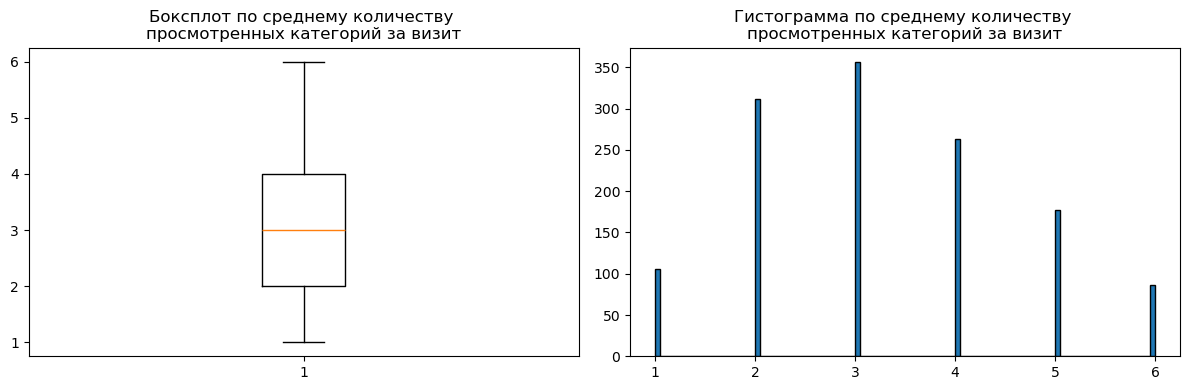

count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: средний_просмотр_категорий_за_визит, dtype: float64

In [44]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['средний_просмотр_категорий_за_визит'])
axes[0].set_title('Боксплот по среднему количеству \nпросмотренных категорий за визит')

# Второй график — гистограмма
axes[1].hist(market['средний_просмотр_категорий_за_визит'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по среднему количеству \nпросмотренных категорий за визит')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['средний_просмотр_категорий_за_визит'].describe()

Дискретное распределение. В данном случае как и в случае с количеством маркетинговых коммуникаций в текущем месяце выборка слишком мала для устойчивых оценок распределения. Для 6 значений статистики и графики могут быть очень чувствительны к каждому элементу. Выводы об общем распределении делать рискованно. Квартильные значения и стандартное отклонение могут быть неустойчивы.

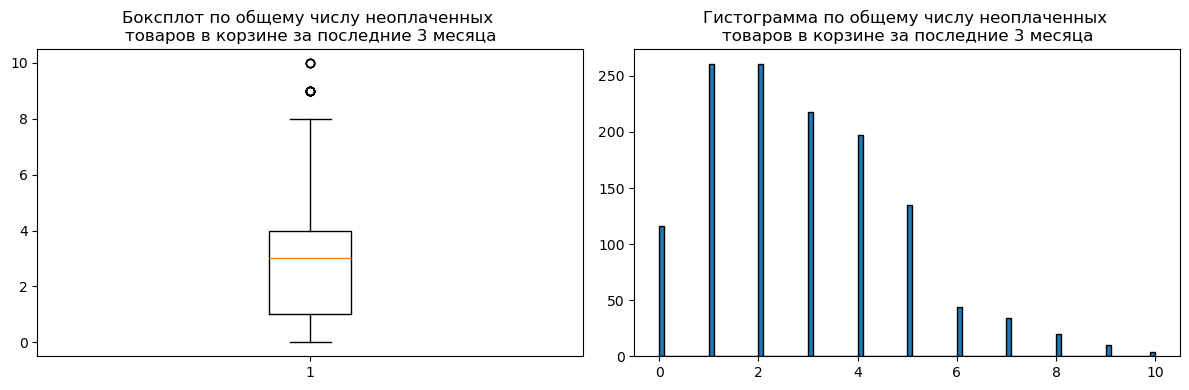

count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64

In [45]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['неоплаченные_продукты_штук_квартал'])
axes[0].set_title('Боксплот по общему числу неоплаченных \nтоваров в корзине за последние 3 месяца')

# Второй график — гистограмма
axes[1].hist(market['неоплаченные_продукты_штук_квартал'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по общему числу неоплаченных \nтоваров в корзине за последние 3 месяца')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['неоплаченные_продукты_штук_квартал'].describe()


Дискретное распределение. Выбросы отсутствуют.

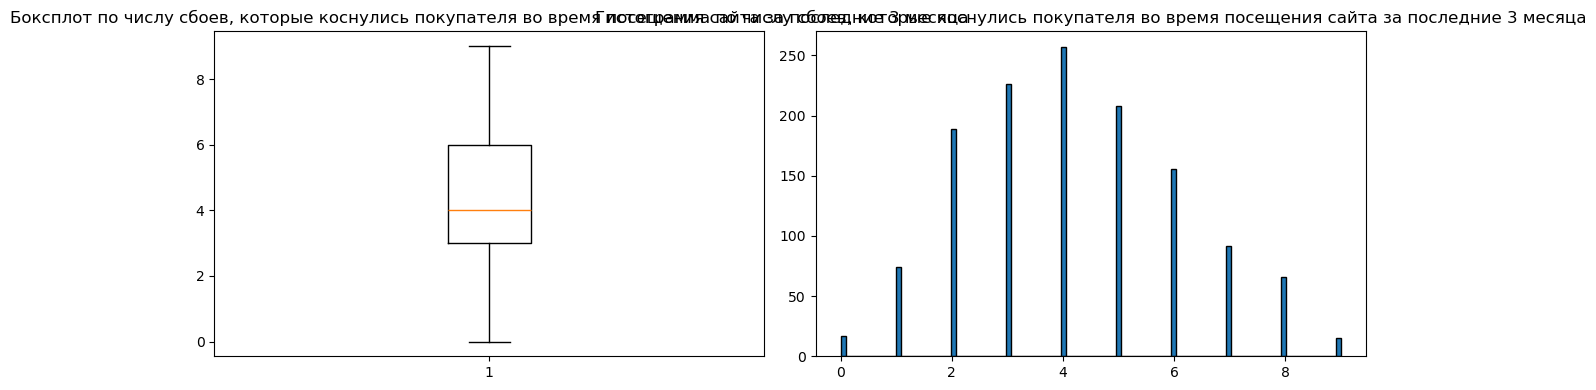

count    1300.000000
mean        4.185385
std         1.955298
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: ошибка_сервиса, dtype: float64

In [46]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['ошибка_сервиса'])
axes[0].set_title('Боксплот по числу сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца')

# Второй график — гистограмма
axes[1].hist(market['ошибка_сервиса'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по числу сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['ошибка_сервиса'].describe()

Распределение близко к нормальному, но является дискретным. Выбросы отсутствуют.

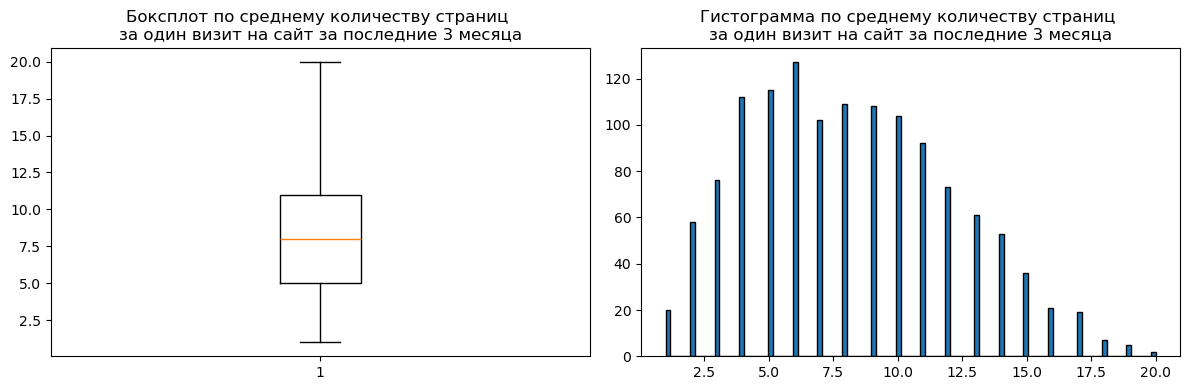

count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64

In [47]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market['страниц_за_визит'])
axes[0].set_title('Боксплот по среднему количеству страниц \nза один визит на сайт за последние 3 месяца')

# Второй график — гистограмма
axes[1].hist(market['страниц_за_визит'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по среднему количеству страниц \nза один визит на сайт за последние 3 месяца')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market['страниц_за_визит'].describe()

Распределение близко к нормальному, но является дискретным. Выбросы отсутствуют.

Таким образом, видим, что в датасете у нас четыре дискретных распределения, одно нормальное и два не являющихся нормальными. В дальнейшем для корреляционного анализа будем использовать phik-матрицу.

Теперь посмотрим на распределения в других датасетах.

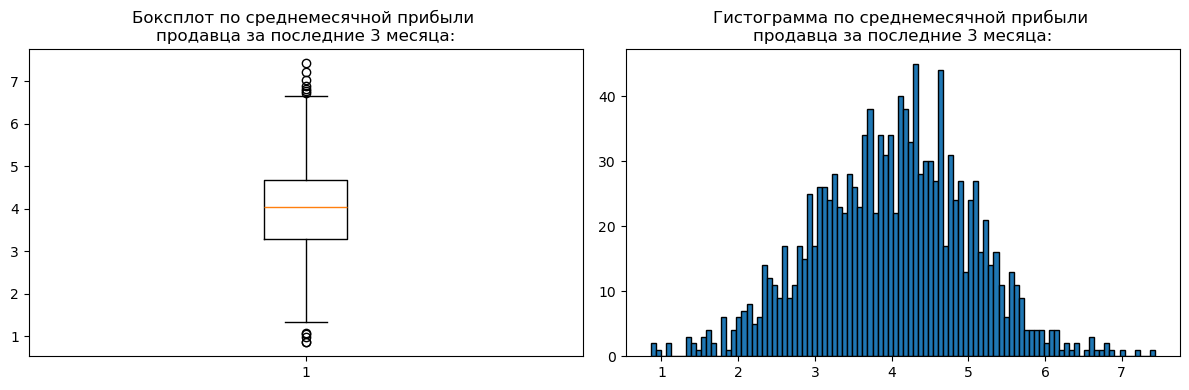

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

In [48]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(money['прибыль'])
axes[0].set_title('Боксплот по среднемесячной прибыли \nпродавца за последние 3 месяца:')

# Второй график — гистограмма
axes[1].hist(money['прибыль'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по среднемесячной прибыли \nпродавца за последние 3 месяца:')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
money['прибыль'].describe()

Видим, что распределение по прибыли близко к нормальному. 

In [49]:
Q1 = money['прибыль'].quantile(0.25)
Q3 = money['прибыль'].quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
money['прибыль'][money['прибыль'] < lower_whisker].count()



5

In [50]:
higher_whisker = Q3 + 1.5 * IQR
money['прибыль'][money['прибыль'] > higher_whisker].count()


7

Хоть выбросов и относительно немного, пока не будем их удалять.

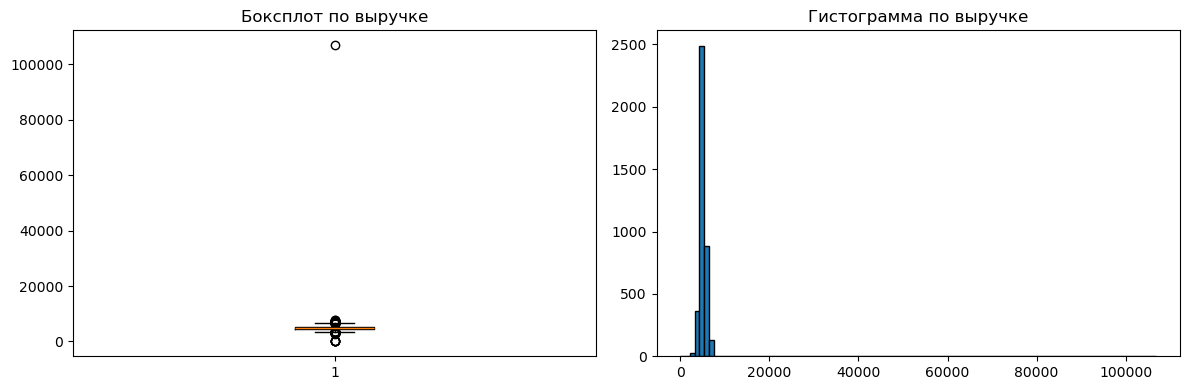

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64

In [51]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market_money['выручка'])
axes[0].set_title('Боксплот по выручке')

# Второй график — гистограмма
axes[1].hist(market_money['выручка'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по выручке')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market_money['выручка'].describe()

In [52]:
market_money[market_money['выручка'] > 100000]

,id,период,выручка
98,215380,текущий_месяц,106862.2


Видим выброс, который явно является аномалией, удалим его.

In [53]:
market_money = market_money[market_money['выручка'] < 100000]

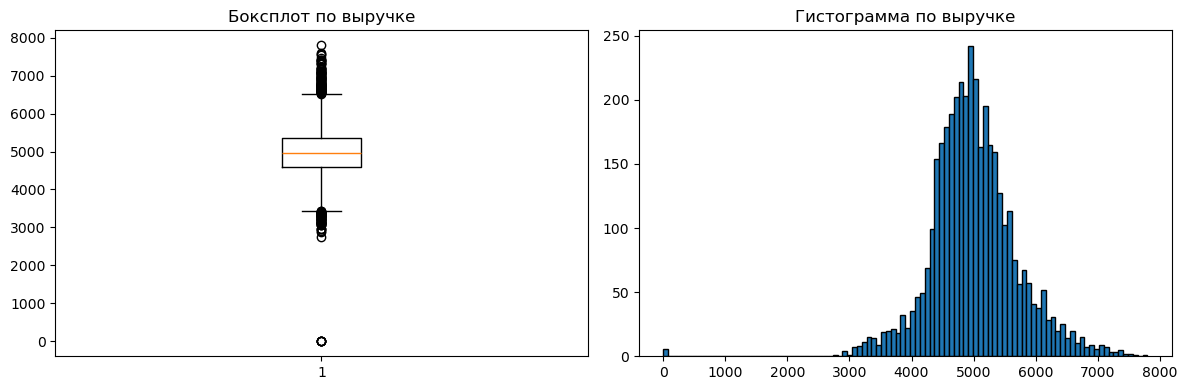

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: выручка, dtype: float64

In [54]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market_money['выручка'])
axes[0].set_title('Боксплот по выручке')

# Второй график — гистограмма
axes[1].hist(market_money['выручка'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по выручке')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market_money['выручка'].describe()

Теперь видна еще несколько выбросов в районе 0, по условиям поставленной задачи, нам как раз необходимо отфильтровать (убрать) тех клиентов, от которых хотя бы в одном периоде отсутствовала выручка.

In [55]:
market_money[market_money['выручка'] < 1]

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
2,215348,предыдущий_месяц,0.0
28,215357,препредыдущий_месяц,0.0
29,215357,предыдущий_месяц,0.0
34,215359,предыдущий_месяц,0.0
35,215359,препредыдущий_месяц,0.0


In [56]:
market_money = market_money[market_money['выручка'] > 1]

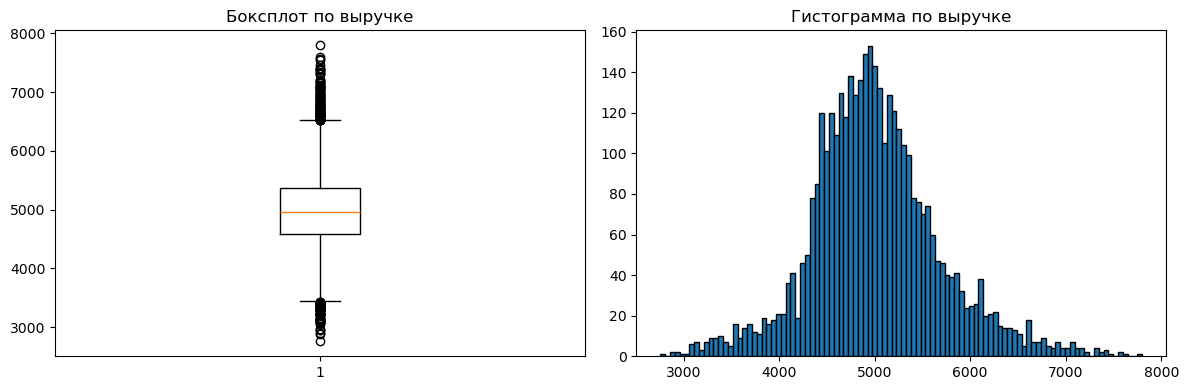

count    3893.000000
mean     5007.282918
std       679.724898
min      2758.700000
25%      4592.000000
50%      4959.000000
75%      5363.000000
max      7799.400000
Name: выручка, dtype: float64

In [57]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(market_money['выручка'])
axes[0].set_title('Боксплот по выручке')

# Второй график — гистограмма
axes[1].hist(market_money['выручка'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по выручке')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
market_money['выручка'].describe()

Нормальное распределение выручки

**Шаг 4. Объединение таблиц**

In [58]:
market_money_wide = market_money.pivot(index='id', columns='период', values='выручка').reset_index()

market_money_wide.columns.name = None
market_money_wide.rename(columns={
    'препредыдущий_месяц': 'выручка_за_препредыдущий_месяц',
    'предыдущий_месяц': 'выручка_за_предыдущий_месяц',
    'текущий_месяц': 'выручка_за_текущий_месяц'
}, inplace=True)

In [59]:
market_money_wide

,id,выручка_за_предыдущий_месяц,выручка_за_препредыдущий_месяц,выручка_за_текущий_месяц
0,215348,NaN,NaN,3293.1
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4
3,215351,6158.0,4793.0,6610.4
4,215352,5807.5,4594.0,5872.5
...,...,...,...,...
1295,216643,3664.0,4704.0,4741.7
1296,216644,4729.0,5299.0,5353.0
1297,216645,5160.0,5334.0,5139.2
1298,216646,4923.0,4725.0,5224.6


В сводную таблицу теперь у нас попали строки,  с хотя бы одним значением выручки за трехлетний период. Однако, учитывая, что на предыдущем шаге для целей нашей задачи мы данные значения удаляли, удалим их и здесь.

In [60]:
market_money_wide = market_money_wide.dropna(subset = ['выручка_за_предыдущий_месяц', 'выручка_за_препредыдущий_месяц', 'выручка_за_текущий_месяц'])

In [61]:
market_money_wide

,id,выручка_за_предыдущий_месяц,выручка_за_препредыдущий_месяц,выручка_за_текущий_месяц
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4
3,215351,6158.0,4793.0,6610.4
4,215352,5807.5,4594.0,5872.5
5,215353,4738.5,5124.0,5388.5
...,...,...,...,...
1295,216643,3664.0,4704.0,4741.7
1296,216644,4729.0,5299.0,5353.0
1297,216645,5160.0,5334.0,5139.2
1298,216646,4923.0,4725.0,5224.6


In [62]:
market_time_wide = market_time.pivot(index='id', columns='период', values='минут').reset_index()

market_time_wide.columns.name = None
market_time_wide.rename(columns={
    'предыдущий_месяц': 'время_за_предыдущий_месяц',
    'текущий_месяц': 'время_за_текущий_месяц'
}, inplace=True)

In [63]:
market_time_wide

,id,время_за_предыдущий_месяц,время_за_текущий_месяц
0,215348,13,14
1,215349,12,10
2,215350,8,13
3,215351,11,13
4,215352,8,11
...,...,...,...
1295,216643,14,7
1296,216644,12,11
1297,216645,12,18
1298,216646,18,7


In [64]:
result = market.merge(market_time_wide, on='id', how='inner') \
            .merge(market_money_wide, on='id', how='inner')

In [65]:
result

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,время_за_предыдущий_месяц,время_за_текущий_месяц,выручка_за_предыдущий_месяц,выручка_за_препредыдущий_месяц,выручка_за_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,14,7,3664.0,4704.0,4741.7
1292,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,12,11,4729.0,5299.0,5353.0
1293,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,12,18,5160.0,5334.0,5139.2
1294,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,18,7,4923.0,4725.0,5224.6


**Шаг 5. Корреляционный анализ**

In [66]:
result_for_phik = result.drop(columns=['id'])

In [67]:
phik_corr = phik_matrix(result_for_phik, interval_cols=['маркет_актив_6_мес','длительность','акционные_покупки','выручка_за_предыдущий_месяц','выручка_за_препредыдущий_месяц', 'выручка_за_текущий_месяц'])

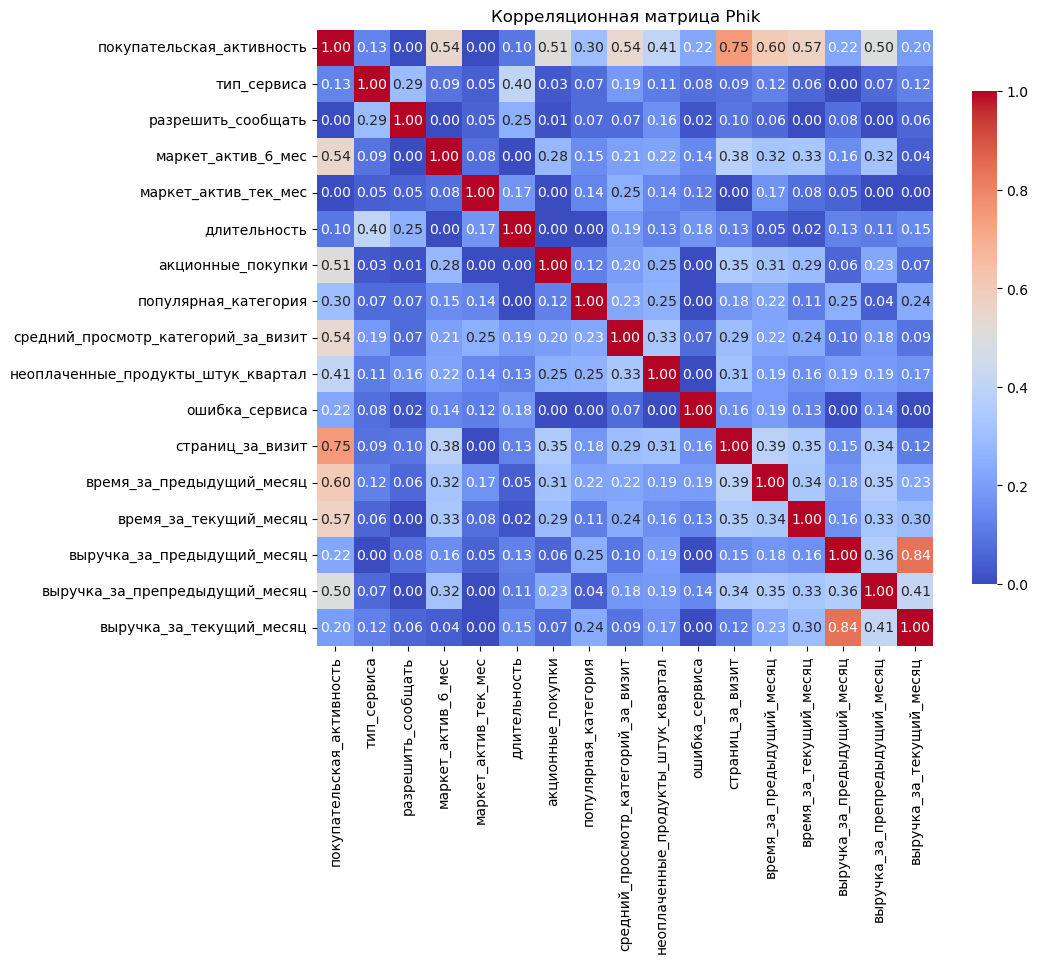

In [68]:
plt.figure(figsize=(10, 8))  
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()


Видим, что сильнее всего целевой признак 'покупательская_активность' связан с признаком 'страниц_за_визит', а также с признаком 'время_за_предыдущий_месяц'. 
Кроме того, нужно отметить, что между двумя признаками 'выручка_за_предыдущий_месяц' и 'выручка_за_препредыдущий_месяц' 0.73 — высокая корреляция. Признак 'акционные покупки' тоже довольно сильно связан с  'выручка_за_предыдущий_месяц' 0.64 и 'выручка_за_препредыдущий_месяц' 0.75.
Но при этом такой связи все же недостаточно, чтобы говорить о мультиколлинеарности признаков.

Кроме того, видим, что у нас есть признаки, которые вообще не связаны с таргетом, а именно: 'разрешить_сообщать', 'маркет_актив_тек_мес', 'выручка_за_текущий_месяц', также очень слабо с таргетом связана 'длительность'.

Создадим гистограммы для в разрезе значений таргета по всем признакам

,Значение,Частота,Процент
0,Прежний уровень,802,61.882716
1,Снизилась,494,38.117284


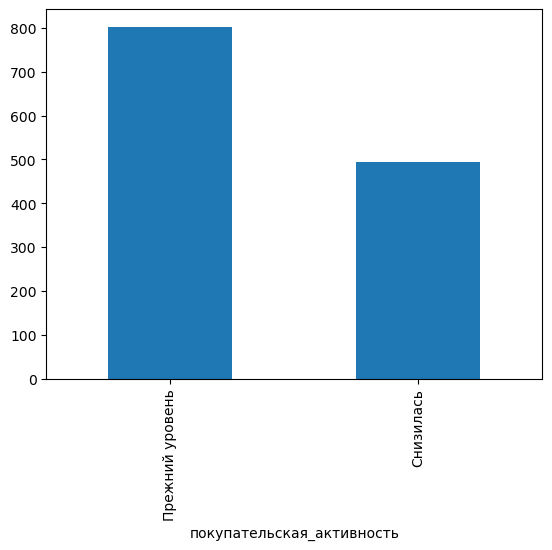

In [69]:
counts = result['покупательская_активность'].value_counts()

counts_df = counts.reset_index()
counts_df.columns = ['Значение', 'Частота']

total = counts.sum()
counts_df['Процент'] = (counts_df['Частота'] / total) * 100

result['покупательская_активность'].value_counts().plot(kind='bar')

counts_df

Видим, что количество пользователей, у которых снизилась активность 494 человека, у которых активность осталась на прежнем уровне - 802 человека.

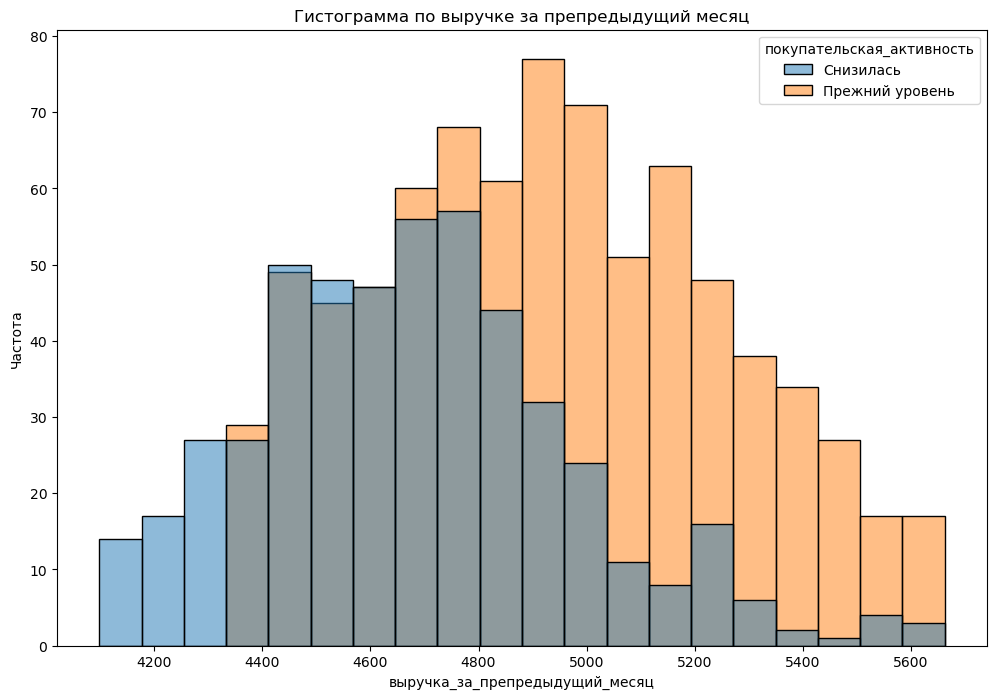

In [70]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='выручка_за_препредыдущий_месяц', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по выручке за препредыдущий месяц')
ax.set_ylabel('Частота')
plt.show()


Видим, что значения выручки за препредыдущий месяц у пользователей, у которых активность снизилась, в среднем ниже, чем у пользователей, у которых активность осталась на прежнем уровне.

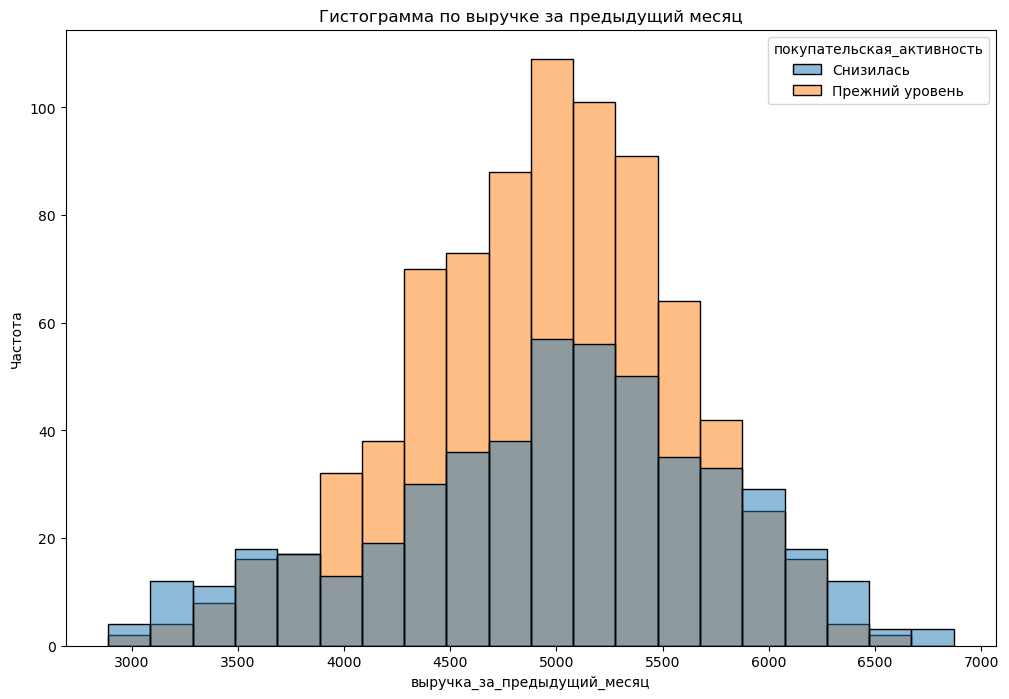

In [71]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='выручка_за_предыдущий_месяц', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по выручке за предыдущий месяц')
ax.set_ylabel('Частота')
plt.show()


видим, что выручка за предыдущий месяц распределена похожим образом у пользователей со снизившейся активностью и с активностью на прежнем уровне

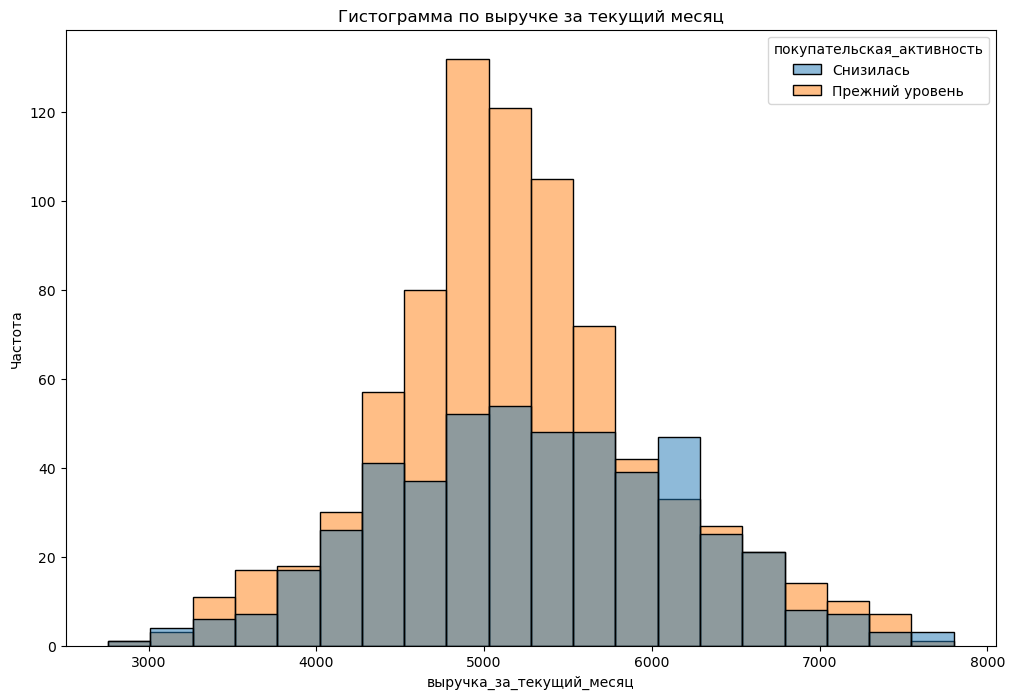

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='выручка_за_текущий_месяц', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по выручке за текущий месяц')
ax.set_ylabel('Частота')
plt.show()

видим, что выручка за текущий месяц распределена похожим образом у пользователей со снизившейся активностью и с активностью на прежнем уровне

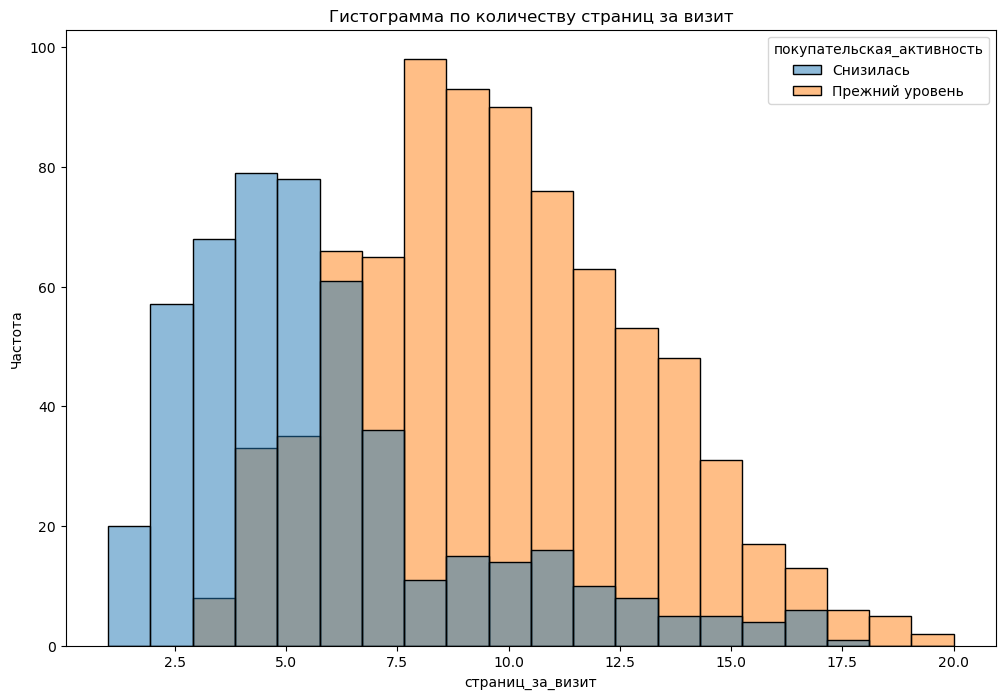

In [73]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='страниц_за_визит', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по количеству страниц за визит')
ax.set_ylabel('Частота')
plt.show()


видим, что в среднем количество страниц за визит у пользователей со снизившейся активностью составляет 4-5 страниц,у пользователей с прежним уровнем активности - 8-10 страниц 

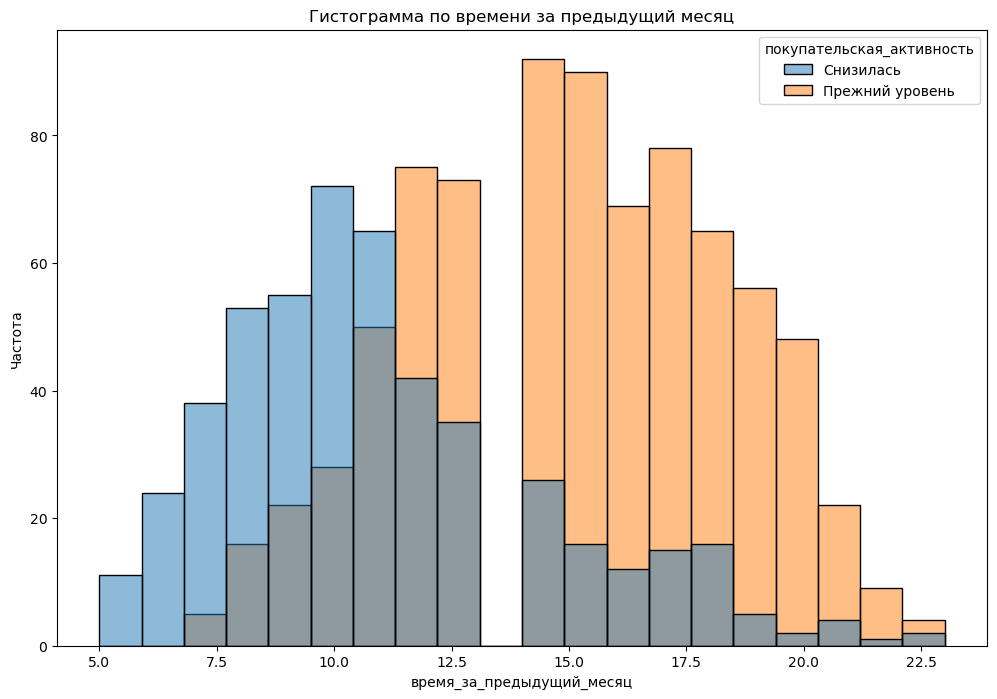

In [74]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='время_за_предыдущий_месяц', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по времени за предыдущий месяц')
ax.set_ylabel('Частота')
plt.show()


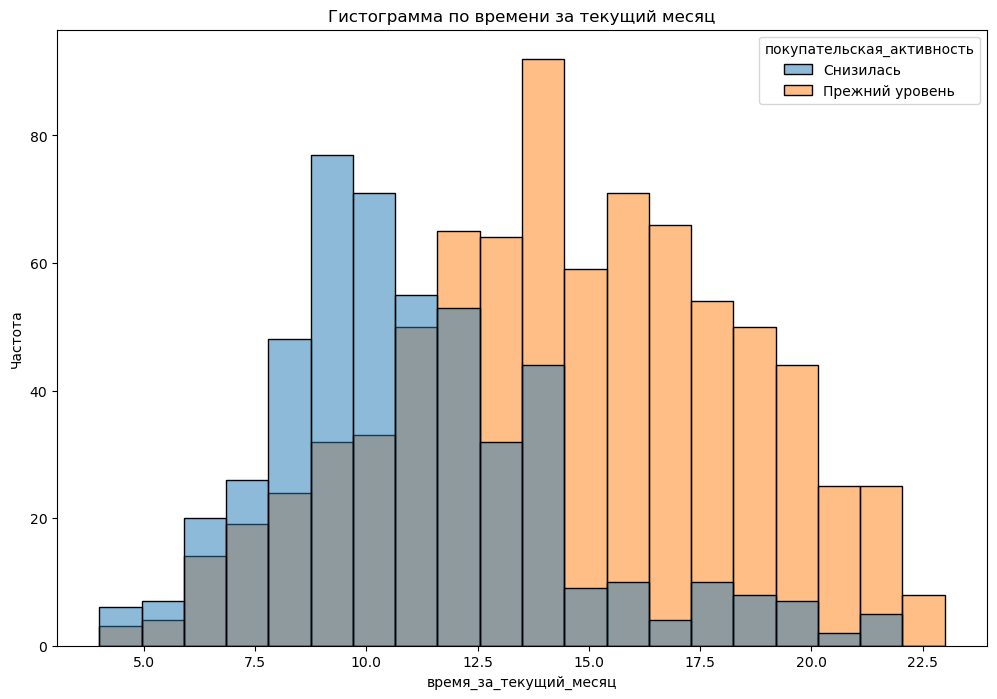

In [75]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='время_за_текущий_месяц', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по времени за текущий месяц')
ax.set_ylabel('Частота')
plt.show()


Видим, что время визита в предыдущем и текущем месяцах у пользователей, у которых снизилась активность в среднем меньше, чем у пользователей с прежним уровнем активности.

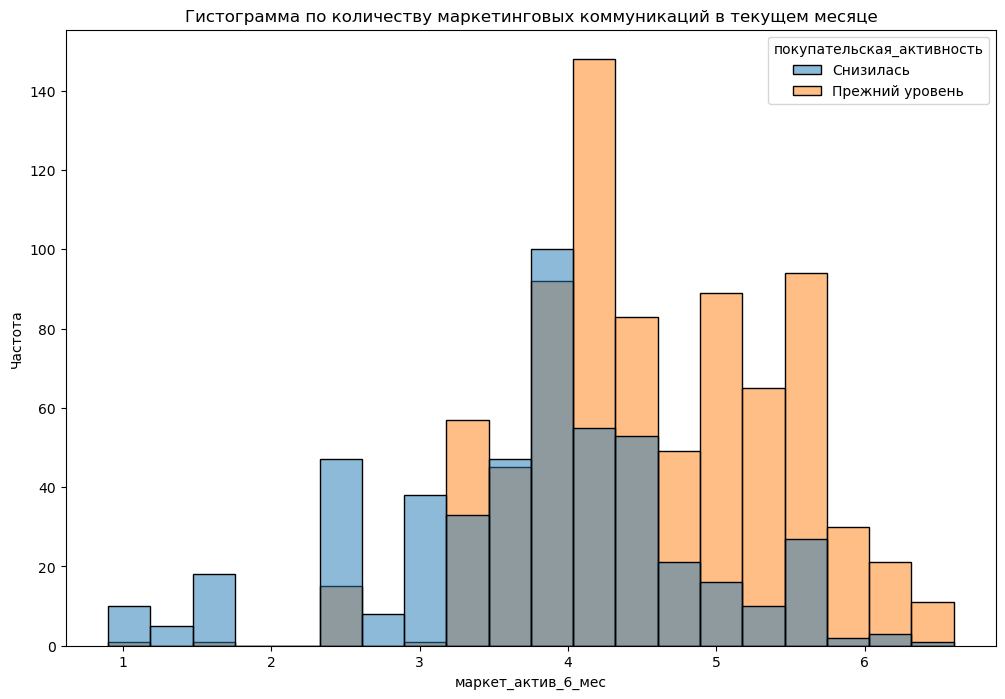

In [76]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='маркет_актив_6_мес', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по количеству маркетинговых коммуникаций в текущем месяце')
ax.set_ylabel('Частота')
plt.show()


видим, что распределение количества маркетинговых коммуникаций по группам пользователей примерно похоже, однако на пользователей со снизившейся активностью все же приходится в среднем меньше маркетинговых коммуникаций

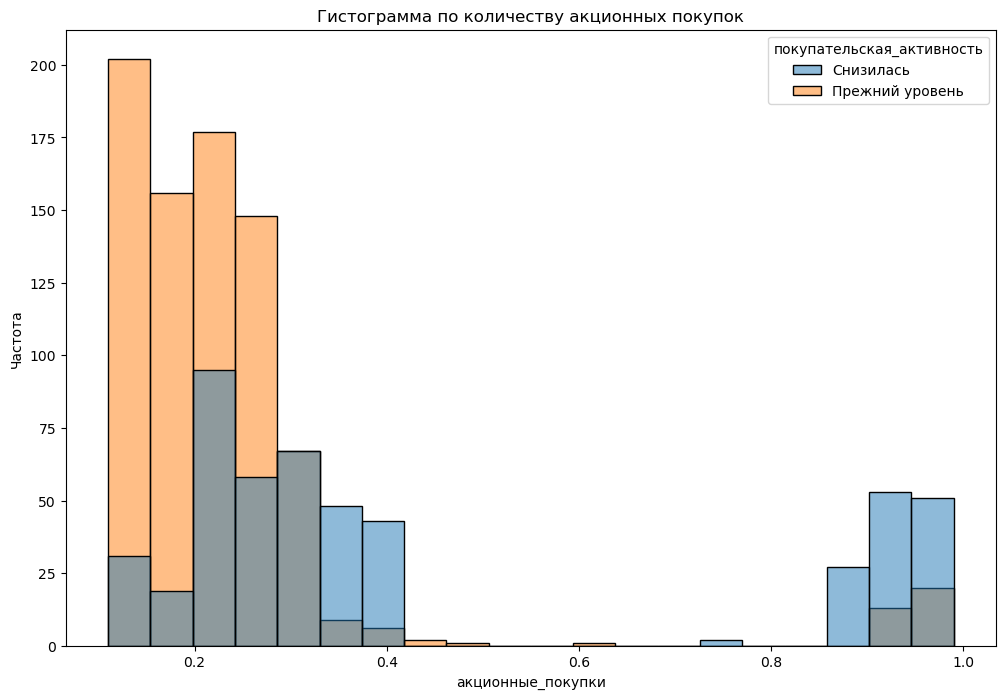

In [77]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='акционные_покупки', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по количеству акционных покупок')
ax.set_ylabel('Частота')
plt.show()


видим, что у основной массы пользователей обеих категорий доля ационных покупок в общем количестве покупоу не превышает 40%, при этом доля пользователй со снизившейся активностью в сегменте пользователей, кто в основнмо покупает лишь товары по акциям (доля акционных покупок больше 85%), в нескоько раз выше долю пользователей с активностью на прежнем уровне.

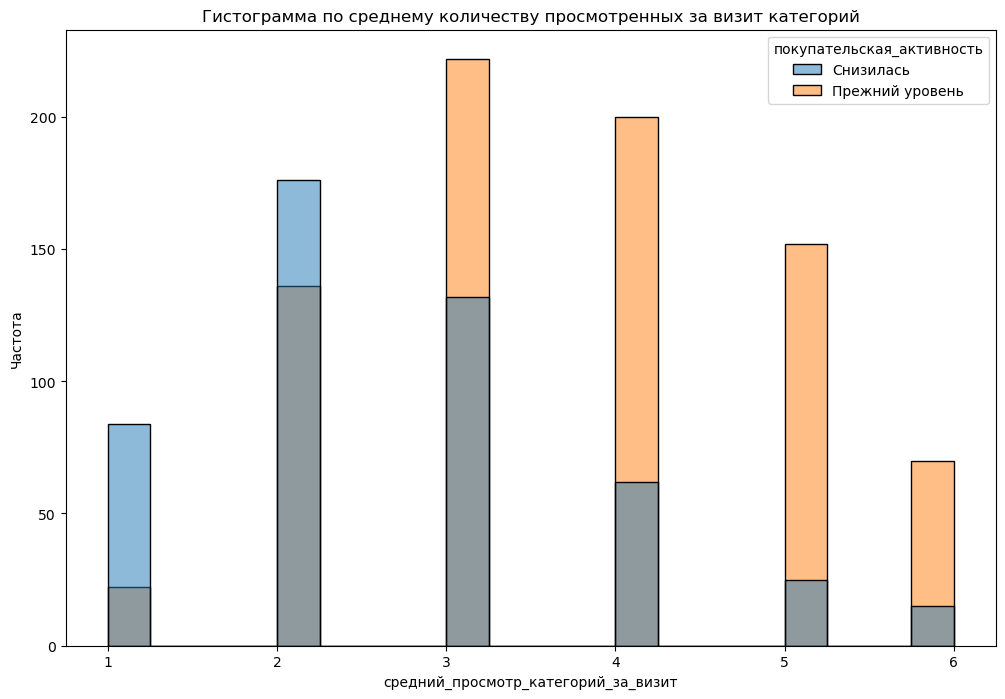

In [78]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='средний_просмотр_категорий_за_визит', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по среднему количеству просмотренных за визит категорий')
ax.set_ylabel('Частота')
plt.show()


видим, что в среднем люди, у уоторых снизилась покупательская активность, смотрят 2-3 категории за визит, а вторая группа пользователей - 3-5 категорий

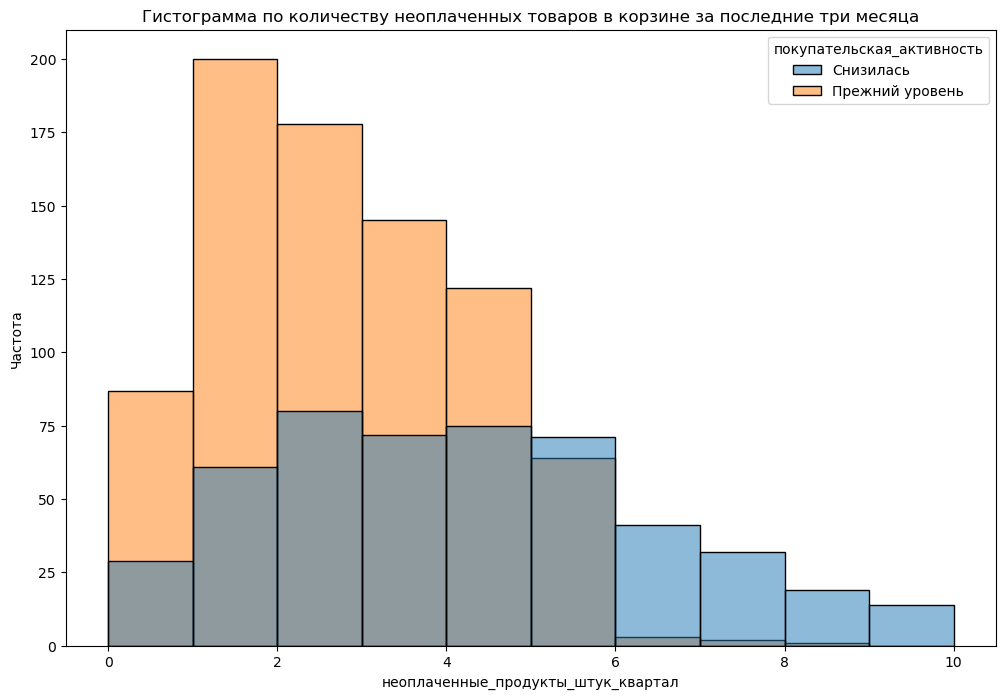

In [79]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='неоплаченные_продукты_штук_квартал', hue='покупательская_активность', bins=10, ax=ax)
ax.set_title('Гистограмма по количеству неоплаченных товаров в корзине за последние три месяца')
ax.set_ylabel('Частота')
plt.show()


видим, что у покупателей, у которых снизилась активность, количество неоплаченных продуктов в корзине больше, чем у пользователей, у которых активность на прежнем уровне

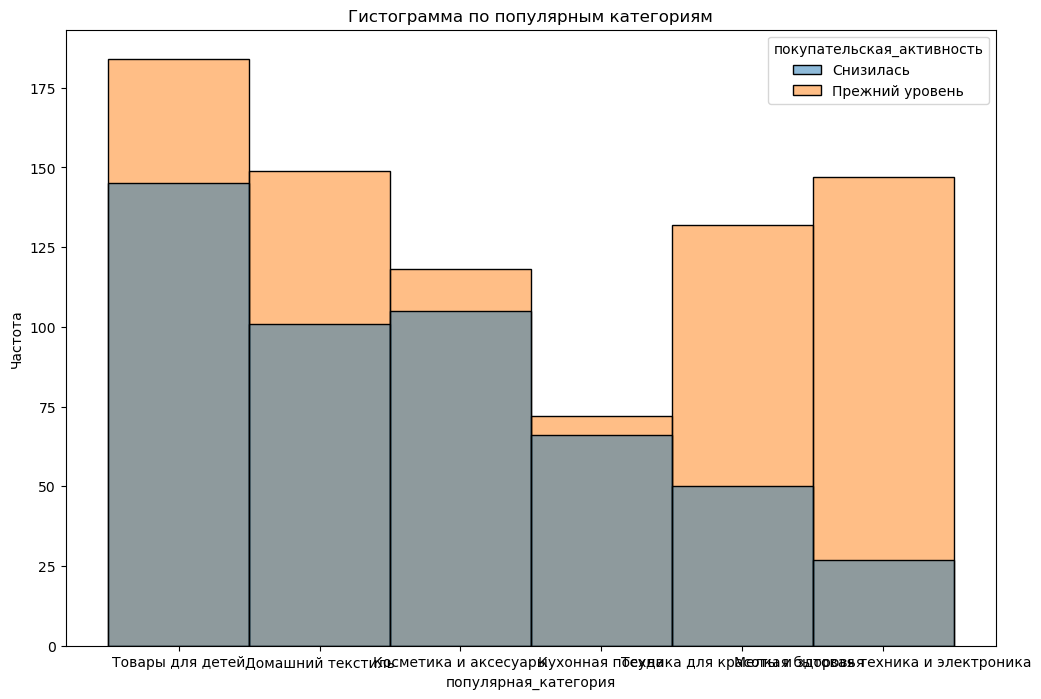

In [80]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='популярная_категория', hue='покупательская_активность', bins=20, ax=ax)
ax.set_title('Гистограмма по популярным категориям')
ax.set_ylabel('Частота')
plt.show()


Наиболее популярная категория у обеих групп пользователей - товары для детей.

***Промежуточный вывод по Шагу 5:*** 

***У пользователей, у которых снизилась покупательская активность, выручка за препредыдущий месяц меньше, чем у второй группы пользователей, за текущий и предыдущий месяцы - примерно на уровне.*** 

***- В среднем первая группа тратила практически в два раза меньше времени за визит, чем вторая группа, в предыдущем и текущем месяцах.*** 

***- В среднем количество страниц за визит у пользователей со снизившейся активностью составляет 4-5 страниц,у пользователей с прежним уровнем активности - 8-10 страниц***

***- На пользователей со снизившейся активностью все же приходится в среднем меньше маркетинговых коммуникаций***

***- У покупателей, у которых снизилась активность, количество неоплаченных продуктов в корзине больше, чем у пользователей, у которых активность на прежнем уровне***

***- В среднем люди, у уоторых снизилась покупательская активность, смотрят 2-3 категории за визит, а вторая группа пользователей - 3-5 категорий***

***-У основной массы пользователей обеих категорий доля ационных покупок в общем количестве покупоу не превышает 40%, при этом доля в сегменте пользователей, кто в основнмо покупает лишь товары по акциям (доля акционных покупок больше 85%), количество пользователй со снизившейся авктивнсотью в несколько раз выше количества пользователей с активностью на прежнем уровне.***

***- Наиболее популярная категория у обеих групп пользователей - товары для детей.***

**Шаг 6. Использование пайплайнов**

In [81]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    result_for_phik.drop(['покупательская_активность'], axis=1),
    result_for_phik['покупательская_активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = result_for_phik['покупательская_активность'])

X_train.shape, X_test.shape



((972, 16), (324, 16))

In [82]:
result_for_phik.columns

Index(['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит', 'время_за_предыдущий_месяц',
       'время_за_текущий_месяц', 'выручка_за_предыдущий_месяц',
       'выручка_за_препредыдущий_месяц', 'выручка_за_текущий_месяц'],
      dtype='object')

In [83]:
# создаём списки с названиями признаков
ohe_columns = ['разрешить_сообщать', 'популярная_категория']
ord_columns = ['тип_сервиса']
num_columns = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', \
               'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', \
              'ошибка_сервиса', 'страниц_за_визит', 'время_за_предыдущий_месяц', 'время_за_текущий_месяц', \
               'выручка_за_текущий_месяц', 'выручка_за_предыдущий_месяц', 'выручка_за_препредыдущий_месяц']

# создаём пайплайн для подготовки признаков с помощью OHE из списка ohe_columns
ohe_pipe = Pipeline(
    [('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]
    )

# создаём пайплайн для подготовки признаков с помощью ORD из списка ord_columns
ord_pipe = Pipeline(
    [('ord',  OrdinalEncoder(
            categories= [['cтандарт', 'премиум']], 
            handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)



# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]  
    },
    
    # словарь для модели SVC()
    {
        'models': [SVC(
            probability=True,
            random_state=RANDOM_STATE
        )],
        'models__C': [0.1, 1, 10, 100],
        'models__kernel': ['linear', 'rbf', 'poly'],
        'models__degree': [2, 3, 4],  
        'models__gamma': ['scale', 'auto'],
        'models__max_iter': [1000, 2000],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
        }
]



<div style="font-size: 18px; background-color:#d9edf7; padding:10px; border-radius:5px;">
<strong>Комментарий по первому коммиту</strong>
    
Увеличил 'models__max_depth' и  'models__max_features' у дерева решений,   'models__n_neighbors' у KNeighborsClassifier и models__C у логистической регрессии.


Положительное значение нашего таргета - активность снизилась. Нам важно точно определить именно тех клиентов, у которых она снизится, чтобы настроить рассылку на них.

При этом у нас нет указаний от бизнеса, какая метрика важнее − полнота или точность. Тогда логично брать баланс.
Поэтому попробуем подобрать оптимальную модель, которая учитывает и полноту, и точность. 

Модель мы строим для перевода бинарных меток классов в вероятности. И нам бы хотелось получить несмещенные откалиброванные вероятности, для этого нужно будет использовать комплексные метрики качества. Поэтому будем использовать метрику roc_auc.

In [84]:

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на валидационной выборке:', randomized_search.best_score_)

# проверка работы модели на тестовой выборке
# расчет прогноза на тестовых данных
y_test_pred = randomized_search.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['разрешить_сообщать',
                                                   'популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('ord',
                                                                   OrdinalEncoder(categories=[['cтандарт',
                                                 

<div style="font-size: 18px; background-color:#d9edf7; padding:10px; border-radius:5px;">
<strong>Комментарий по первому коммиту</strong>
Не удалось добиться прироста метрик по сравнению с первоначальным вариантом.
</div>


Видим, что лучше всего себя показала модель SVC

**Шаг 7. Анализ важности признаков**

PermutationExplainer explainer: 325it [02:21,  2.19it/s]                                                                                                              


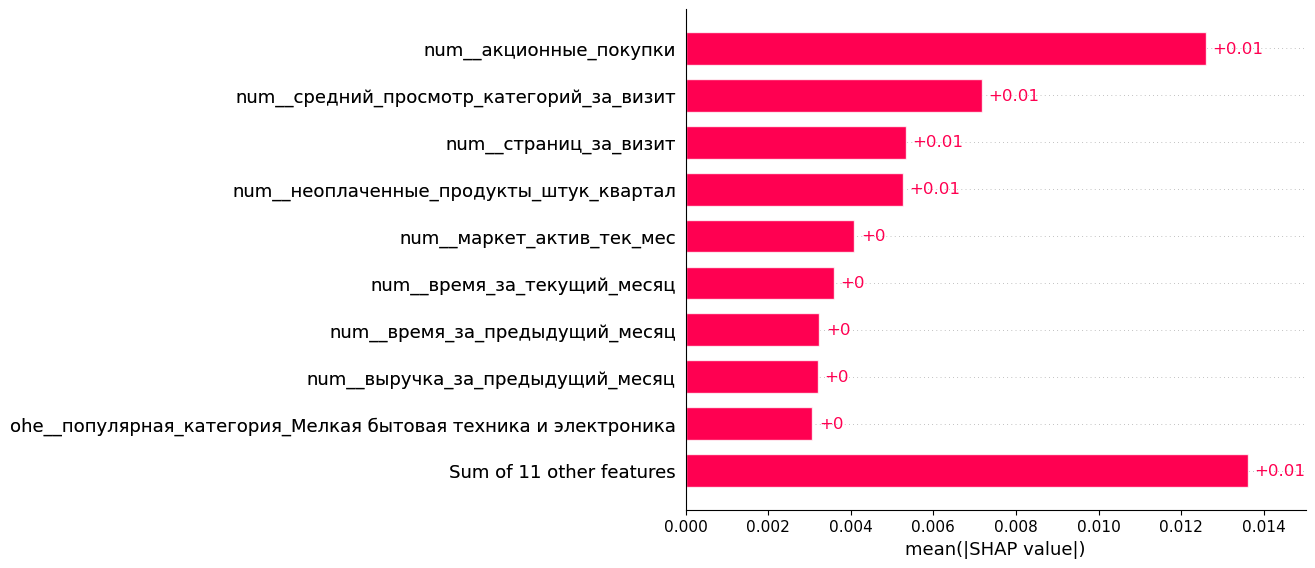

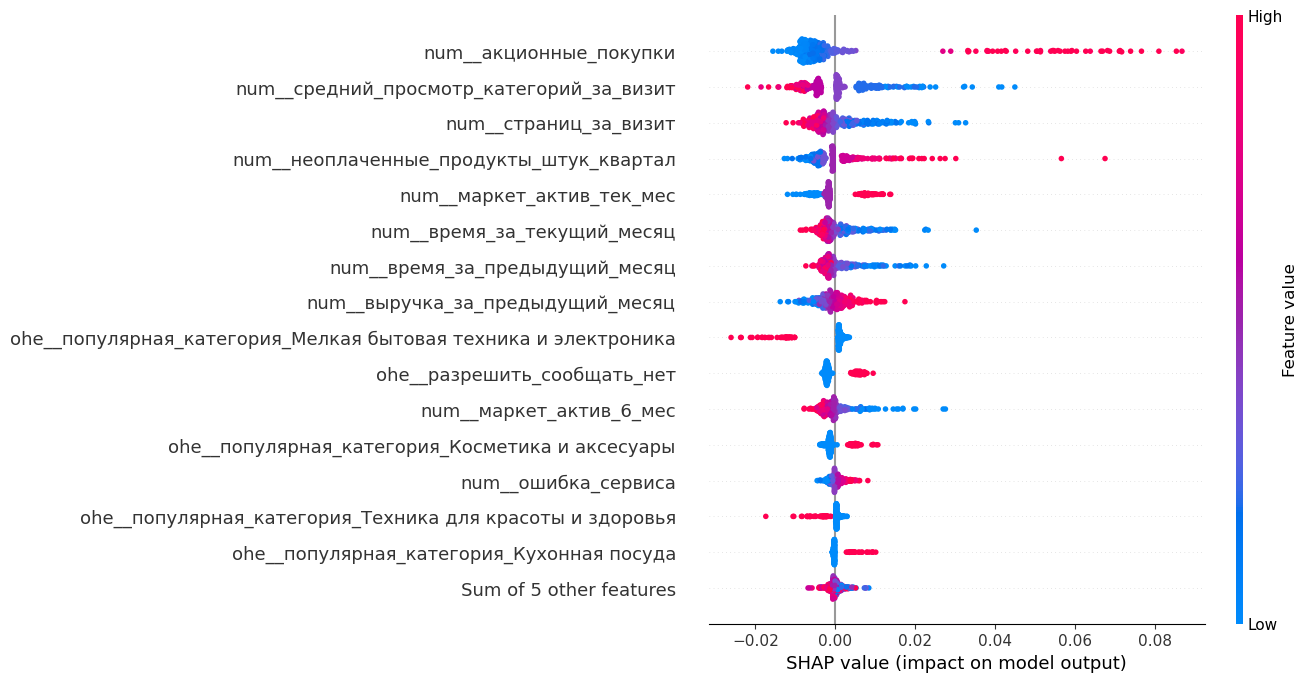

In [85]:
# преобразуем данные обучающей выборки
X_train =  pipe_final.named_steps['preprocessor'].fit_transform(X_train)
X_summary = shap.sample(X_train, nsamples=50)

# создадим объект explainer
explainer = shap.Explainer(randomized_search.best_estimator_.named_steps['models'].predict_proba, X_summary)

# преобразуем данные тестовой выборки
X_test_transformed = pipe_final.named_steps['preprocessor'].transform(X_test)

# получим имена признаков
feature_names = pipe_final.named_steps['preprocessor'].get_feature_names_out()

# создадим датафрейм для тестовых данных с именами признаков
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# посчитаем значения SHAP для тестовых данных
shap_values = explainer(X_test_transformed)

# визуализируем значения SHAP в виде столбчатой диаграммы
shap.plots.bar(shap_values[..., 1])
shap.plots.beeswarm(shap_values[..., 1], max_display=16)

Согласно графику общей значимости признаков наиболее важными признаками по всем наблюдениям являются 'страниц_за_визит', 'время_за_предыдущий_месяц', 'акционные_покупки', 'время_за_текущий_месяц', 'средний_просмотр_категорий_за_визит'

По второму графику видим, что чем выше значений признаков 'страниц_за_визит', 'время_за_предыдущий_месяц',  'время_за_текущий_месяц', 'средний_просмотр_категорий_за_визит', 'выручка_за_препредыдущий_месяц', 'маркет_актив_за6_мес'
заставляют модель классифицировать наблюдения ак принадлежащие к классу 0 (покупательская активность на прежнем уровне).

А высокие значения признаков 'акционные_покупки', 'неоплаченные_продукты_штук_квартал' напротив перетягивают наблюдения к классу 1 (активность снизилась).


**Шаг 8. Сегментация покупателей**

В ходе исследовательского анализа мы увидели, что среди пользователей, которые совершают покупки только по акциям (доля акционных покупок в общем количестве покупок составляет более 85%) в несколько раз преобладают как раз пользователи, у которых покупательская активность снизилась.

Корреляционный анализ показал среднюю связь признака "акционные_покупки" с целевым признаком.

И наконец, в ходе анализа важности признаков, мы увидели, что значение признака "акционные_покупки" весьма высоко, и модель тем охотнее  присваивает класс 1 (активность снизилась), чем выше значение данного признака.

Выделим в качестве исследуемого сегмента людей, чья покупательская активность снизилась, при этом они покупают по большей части лишь акцонные товары (доля акционных покупок в общем количестве покупок от 85% и более).

In [86]:
result['вероятность_снижения_активности'] = randomized_search.predict_proba(result)[:, 1]

In [87]:
result = result.merge(money, on='id', how='inner') 

In [88]:
result.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,время_за_предыдущий_месяц,время_за_текущий_месяц,выручка_за_предыдущий_месяц,выручка_за_препредыдущий_месяц,выручка_за_текущий_месяц,вероятность_снижения_активности,прибыль
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6,0.976484,4.16
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4,0.541283,3.13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4,0.825721,4.87
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5,0.954652,4.21
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5,0.817229,3.95


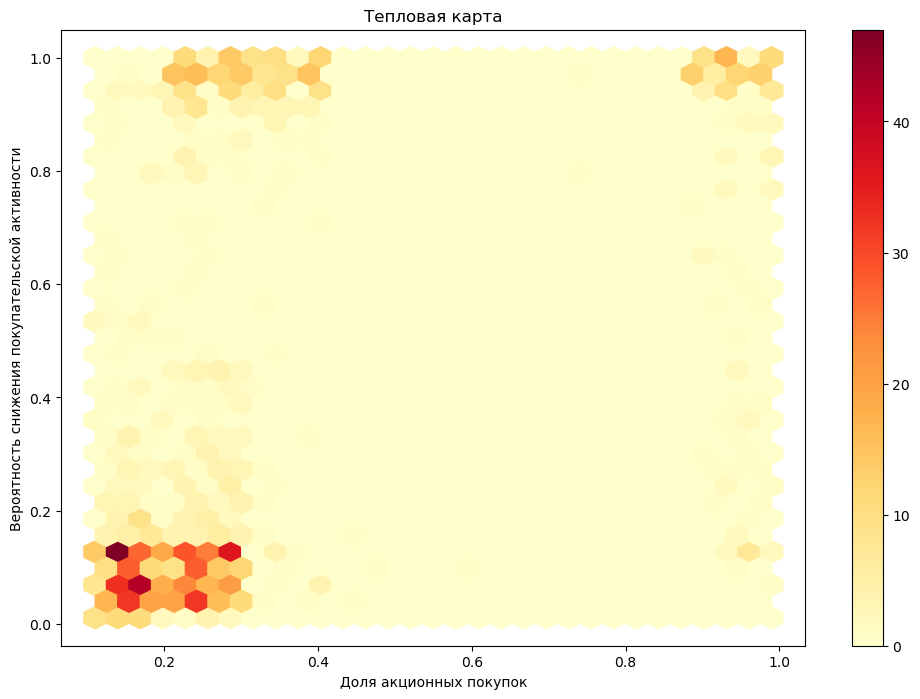

In [89]:
plt.figure(figsize=(12, 8))
plt.hexbin(result['акционные_покупки'], result['вероятность_снижения_активности'], gridsize=30, cmap='YlOrRd')
plt.xlabel('Доля акционных покупок')
plt.ylabel('Вероятность снижения покупательской активности')
plt.title('Тепловая карта')
plt.colorbar()  # шкала интенсивности
plt.show()

Видим выбранный целевой сегмент в правом верхнем углу

In [90]:
segment = result[result['акционные_покупки'] > 0.85].sort_values(by='вероятность_снижения_активности', ascending=False)

In [91]:
segment

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,время_за_предыдущий_месяц,время_за_текущий_месяц,выручка_за_предыдущий_месяц,выручка_за_препредыдущий_месяц,выручка_за_текущий_месяц,вероятность_снижения_активности,прибыль
275,215627,Снизилась,стандарт,да,4.0,3,451,0.89,Домашний текстиль,2,4,3,2,8,6,5022.0,4527.0,4470.8,0.999987,4.92
22,215373,Снизилась,премиум,нет,3.8,3,811,0.90,Товары для детей,2,5,5,3,10,8,4632.0,4293.0,5161.1,0.997233,3.69
58,215410,Снизилась,стандарт,да,3.0,3,1048,0.89,Товары для детей,4,5,3,1,6,4,4839.0,4248.0,4607.6,0.996479,4.46
298,215650,Снизилась,стандарт,нет,3.1,3,810,0.89,Домашний текстиль,4,4,4,3,9,6,5961.0,4698.0,6510.9,0.996290,2.54
111,215463,Снизилась,стандарт,нет,3.1,4,472,0.99,Домашний текстиль,2,6,3,3,8,12,5196.0,4470.0,5015.3,0.995604,3.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,216340,Прежний уровень,стандарт,да,4.9,3,854,0.99,Техника для красоты и здоровья,2,0,4,6,14,22,4711.0,4876.0,4984.0,0.129061,5.15
1172,216524,Прежний уровень,стандарт,нет,4.9,3,326,0.95,Мелкая бытовая техника и электроника,3,2,3,13,20,13,4503.0,5379.0,3873.8,0.129043,3.48
1093,216445,Прежний уровень,стандарт,да,4.9,5,307,0.99,Техника для красоты и здоровья,1,2,6,9,18,9,3061.0,4351.0,4309.0,0.129028,3.45
1108,216460,Прежний уровень,стандарт,да,4.4,5,237,0.95,Техника для красоты и здоровья,4,3,4,4,15,22,4602.0,4845.0,4942.6,0.098747,5.29


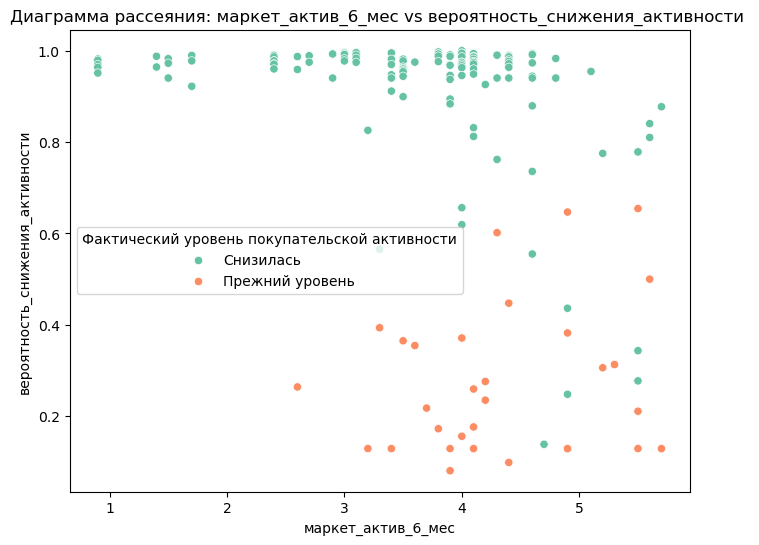

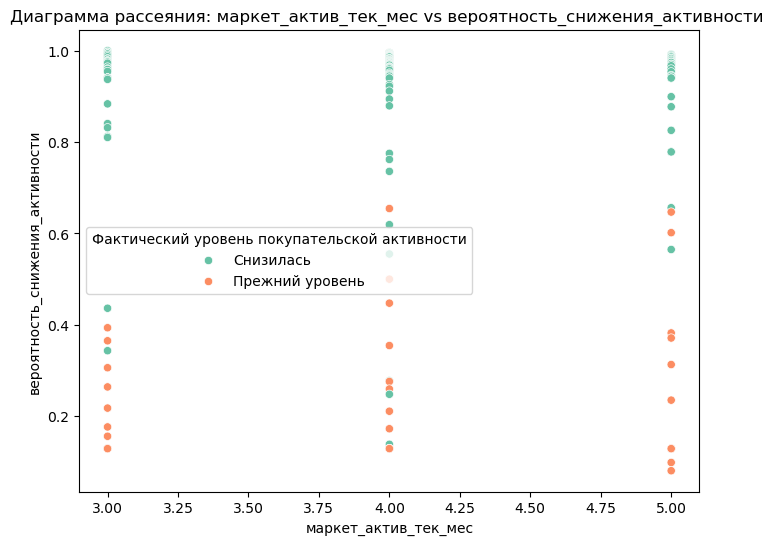

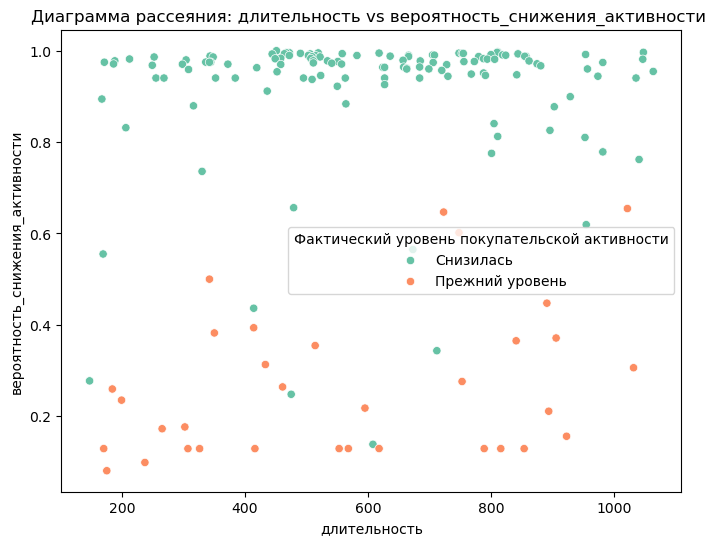

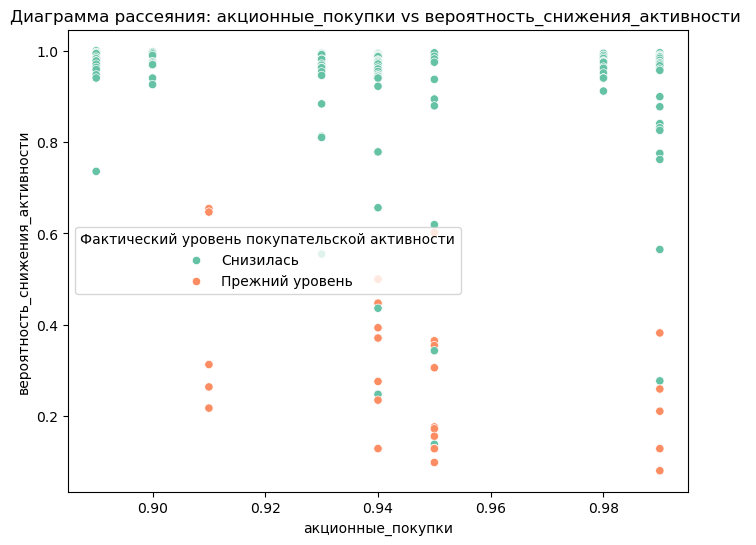

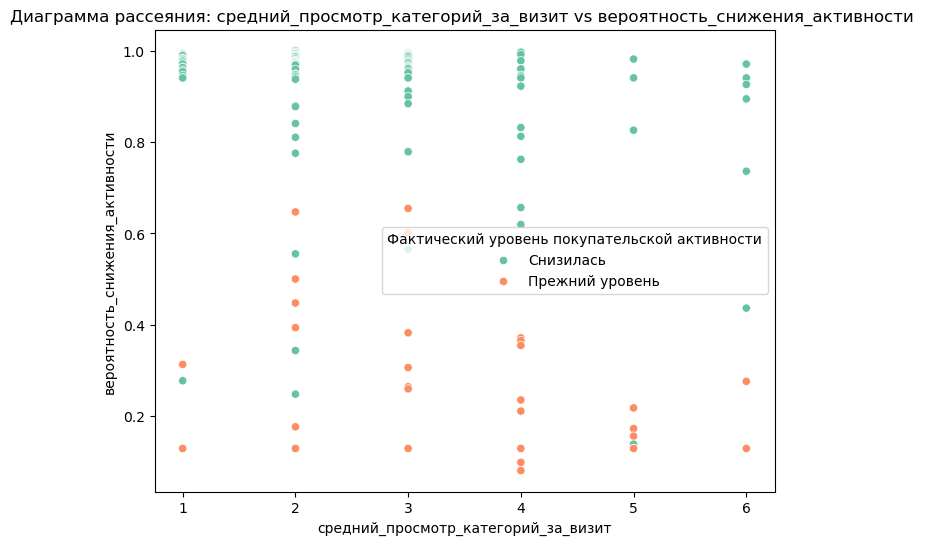

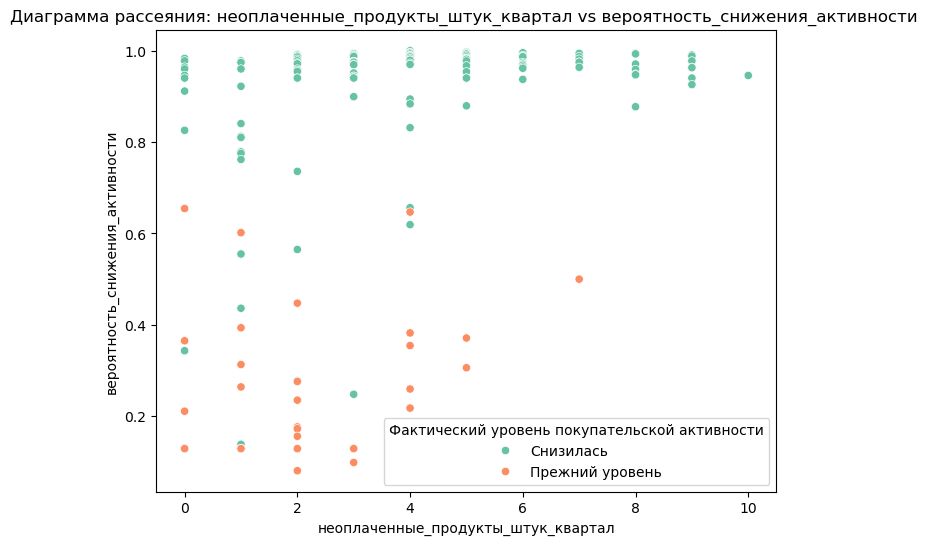

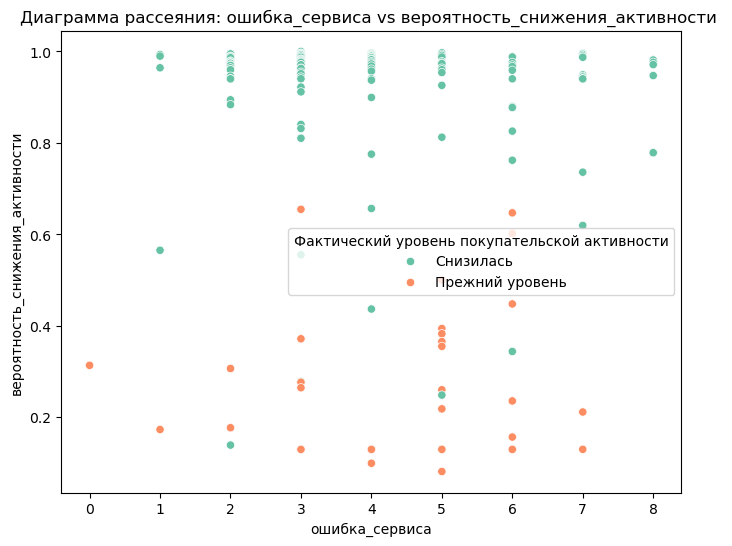

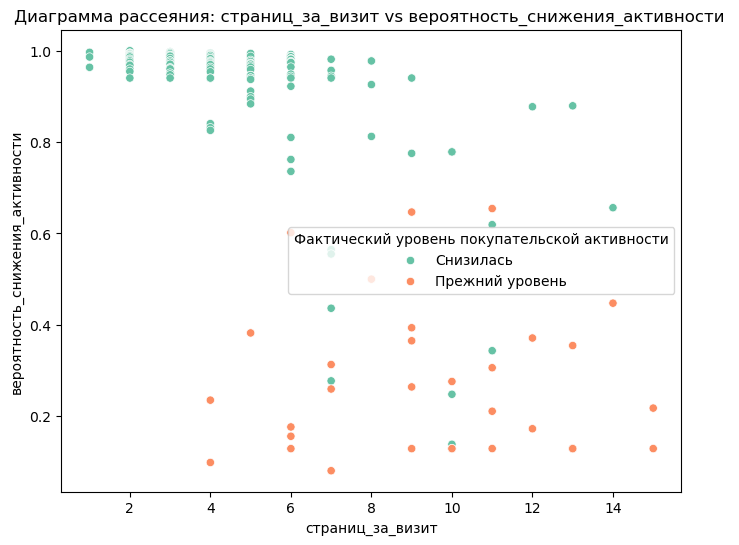

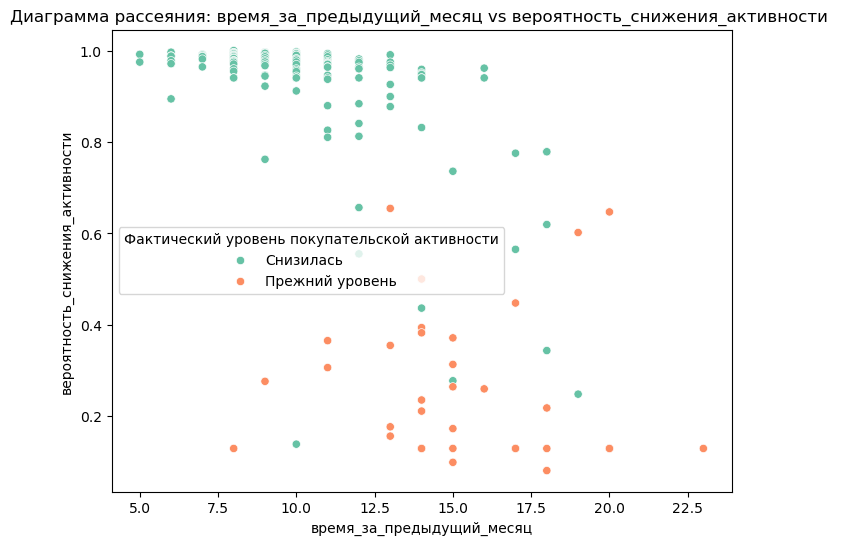

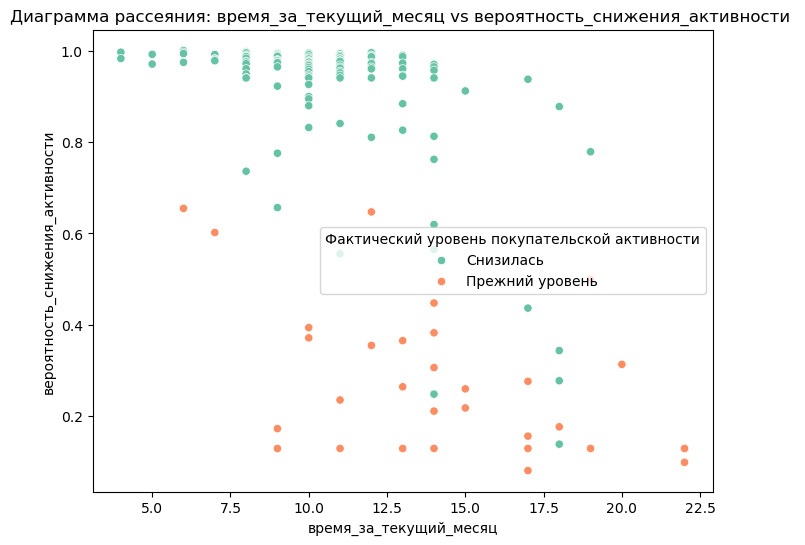

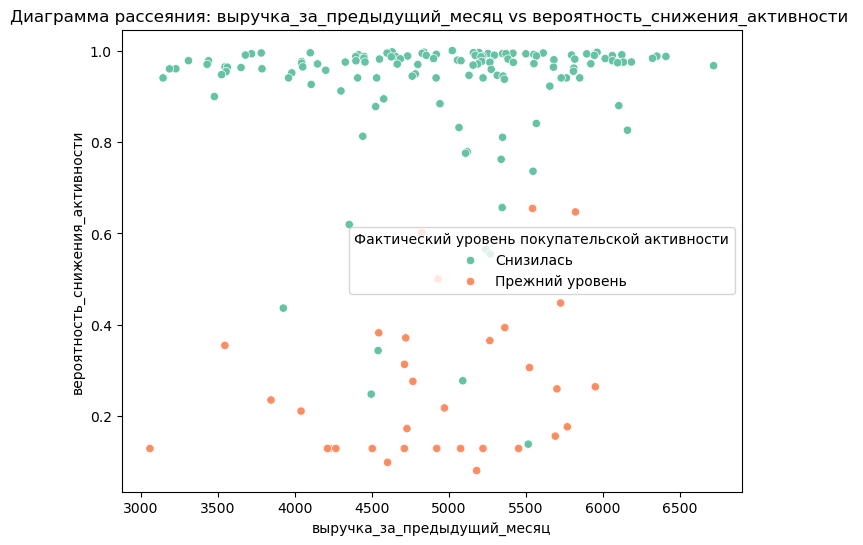

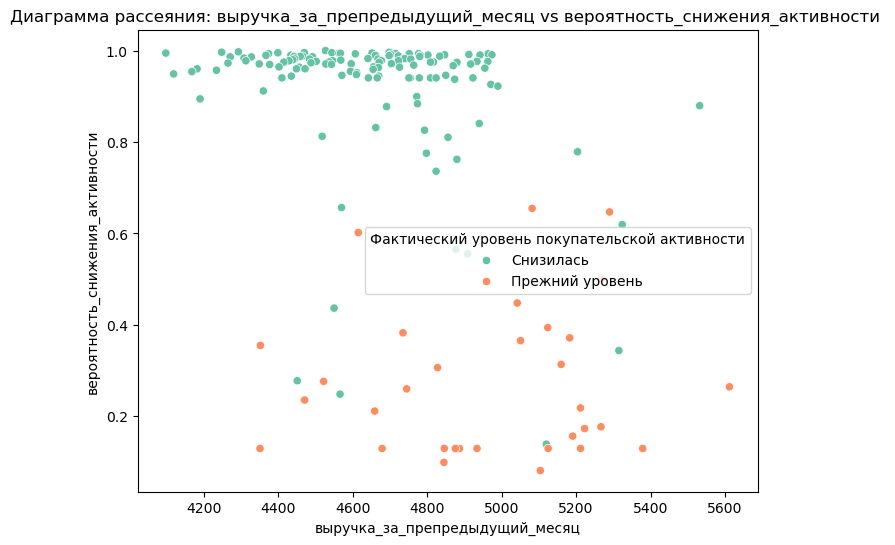

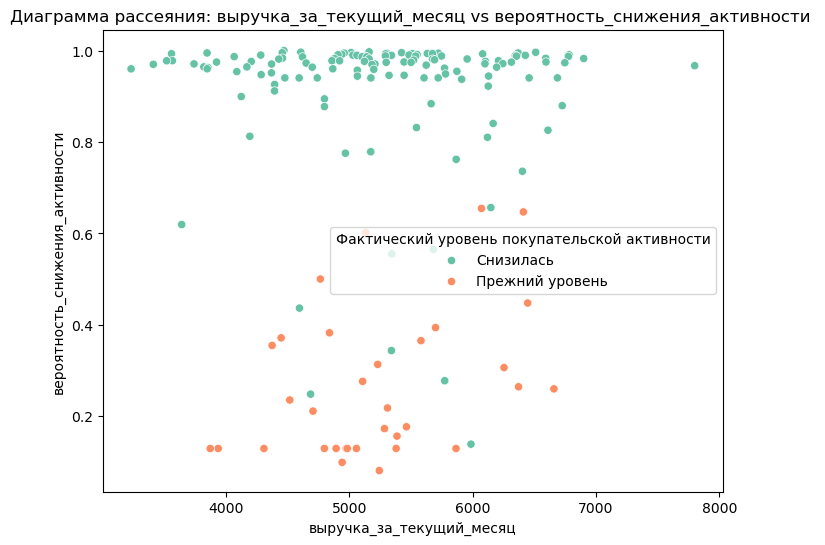

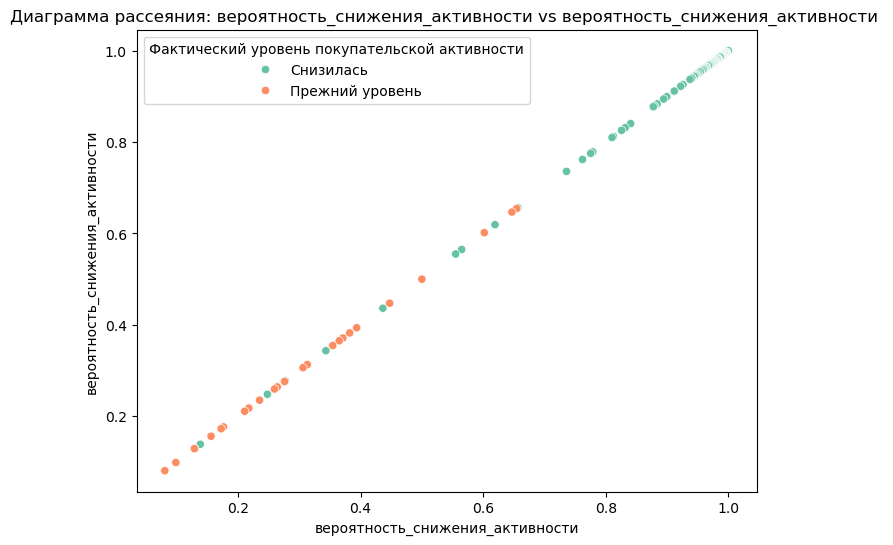

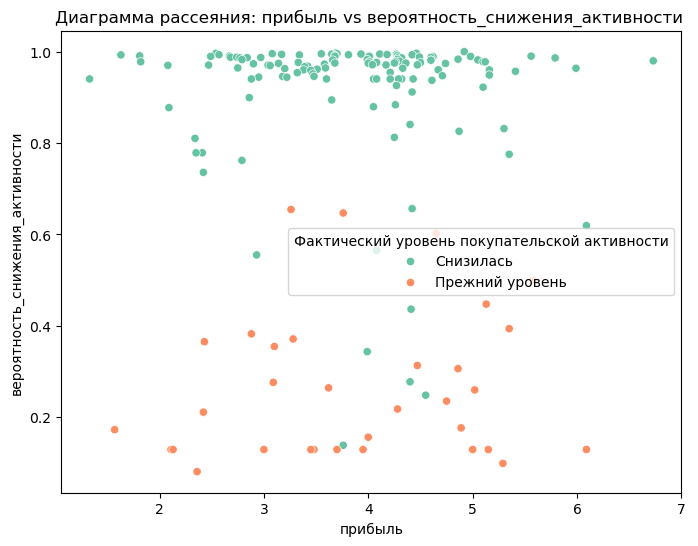

In [92]:
# список всех количественных признаков, кроме 'Удой, кг'
quant_features = [col for col in segment.columns if col not in ['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']]

# цикл по каждому количественному признаку
for feature in quant_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=segment,
        x=feature,
        y='вероятность_снижения_активности',
        hue='покупательская_активность',
        palette='Set2' 
    )
    plt.title(f'Диаграмма рассеяния: {feature} vs вероятность_снижения_активности ')
    plt.xlabel(feature)
    plt.ylabel('вероятность_снижения_активности')
    plt.legend(title='Фактический уровень покупательской активности')
    plt.show()

Видим, что в нашем сегменте по количеству страниц за визит значения положительного класса сосредоточены в диапазоне от 1 до 7 страниц, тогда как значения отрицательного - от 7 до 14. То есть люди с высокой покупательской активностью просматривают больше страниц. Помним, что согласно SHAP самым важным признаком для классификации модели является как раз количество страниц за визит. Вспомним phik-матрицу, признак 'страниц_за_визит' кроме высокой связи с таргетом был связан умеренно (коэффициент 0.38) с признаком 'маркет_актив_6_мес'. Возможно, мы могли бы порекомендовать бизнесу увеличить среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя, при этом эффект в увеличении страниц за визит не будет быстрым ('маркет_актив_тек_месяц' вообще не связан с признаком 'страниц_за_визит').

Кроме того, в нашем сегменте 
- по времени за предыдущий месяц значения положительного класса сосредоточены в диапазоне от 5 до 14 страниц, тогда как значения отрицательного - от 14 до 20;
- по времени за предыдущий месяц значения положительного класса сосредоточены в диапазоне от 3 до 14 страниц, тогда как значения отрицательного - от 9 до 22.
Люди с высокой покупательской активностью просматривают тратили больше времени как в текущем так и в предыдущем месяцах. Эти признаки также важны с точки зрения принятия моделью решения о классификации, и они также умеренно связаны с признаком 'маркет_актив_6_мес'. 

Если смотреть на выручку, то видим, что по положительному классу выручка была сосредоточена:
- за препредыдущий месяц в основном в диапазоне от 4300 до 5000;
- за предыдущий месяц в диапазоне в диапазоне от 3500 до 6250;
- за предыдущий месяц в диапазоне в диапазоне от 3500 до 6250.

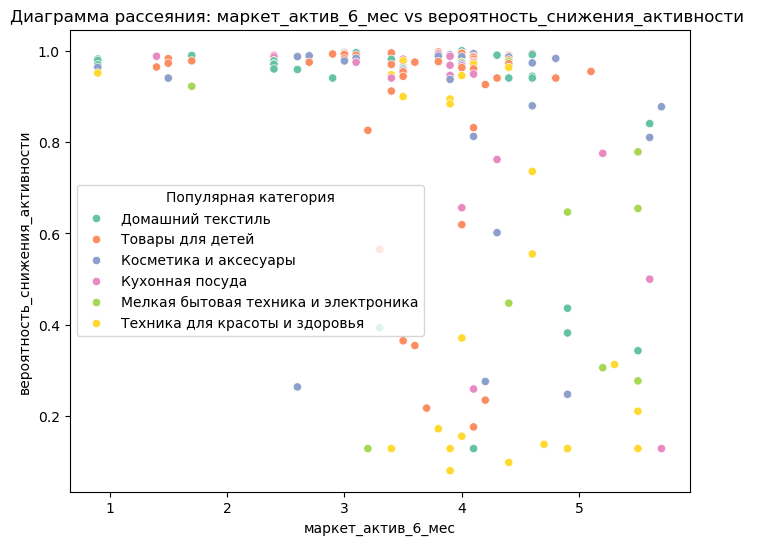

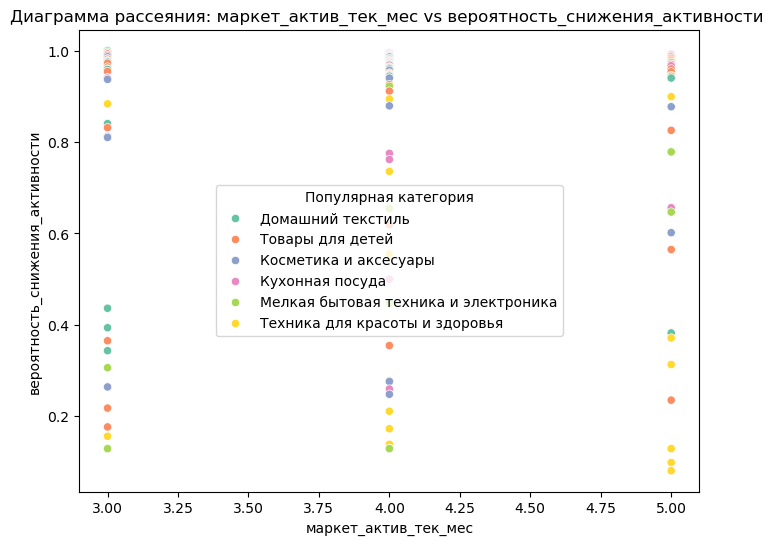

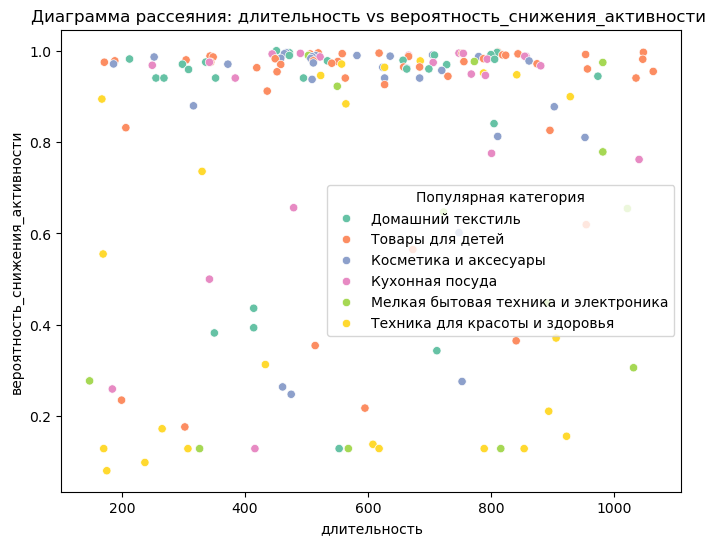

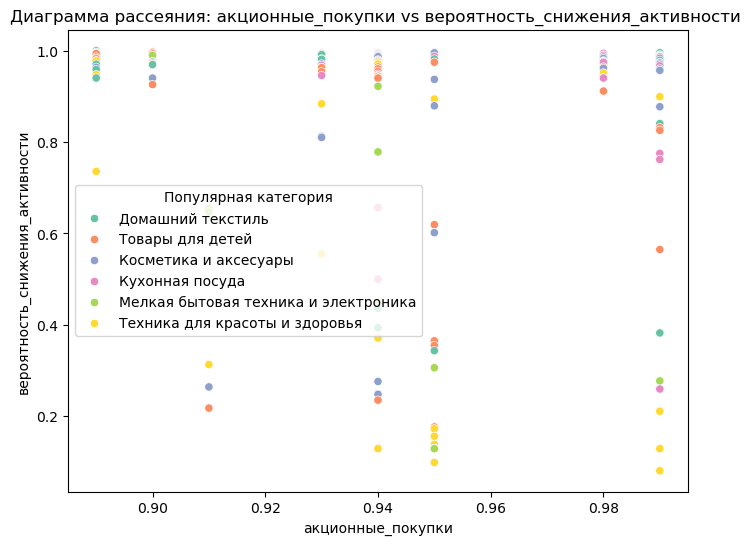

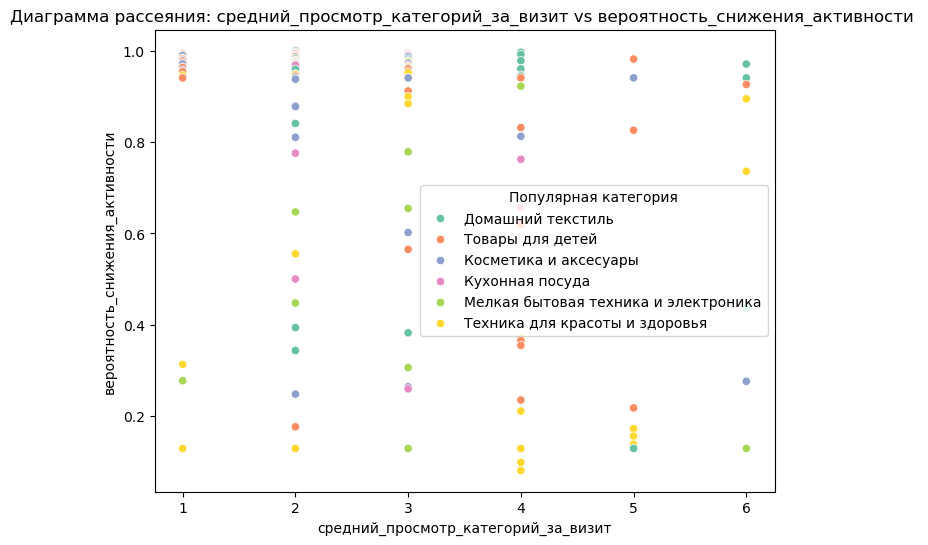

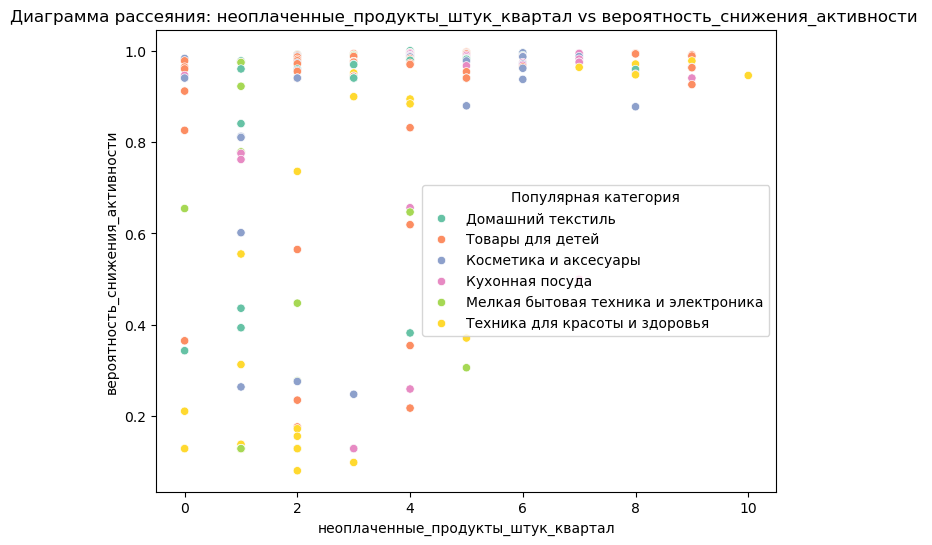

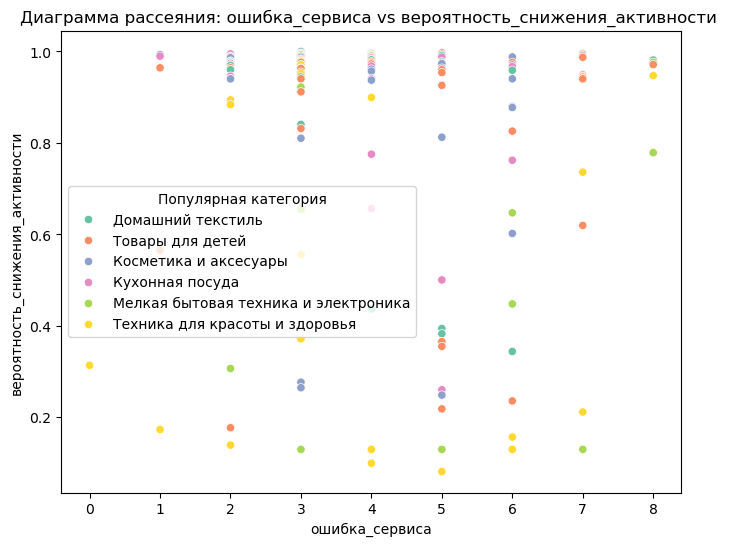

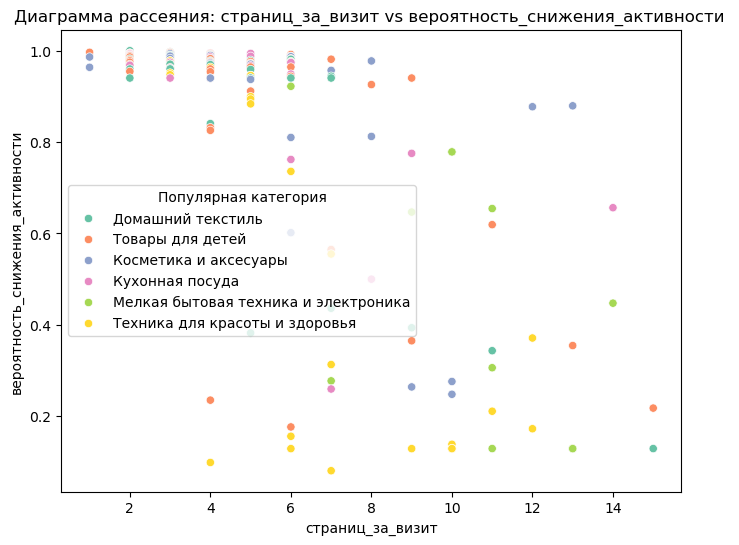

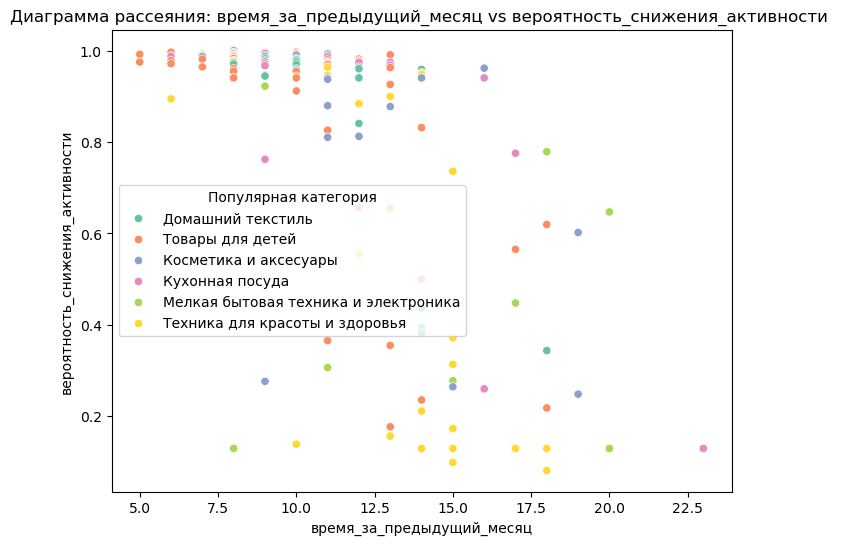

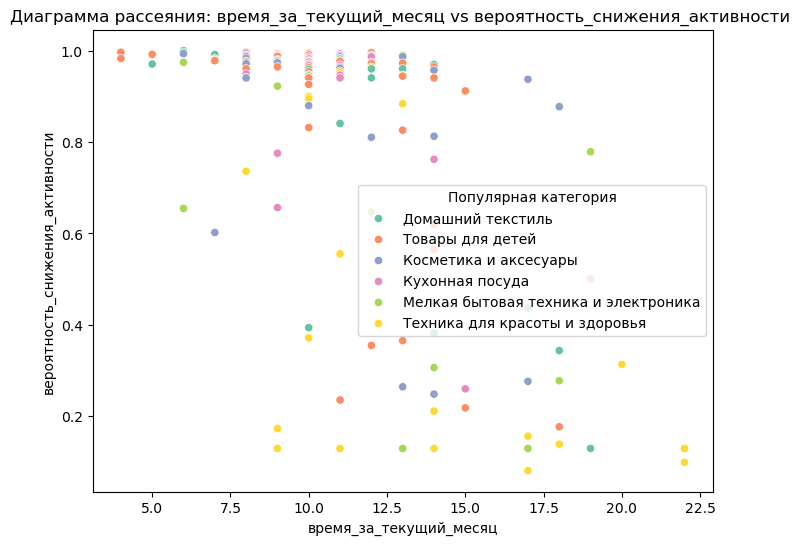

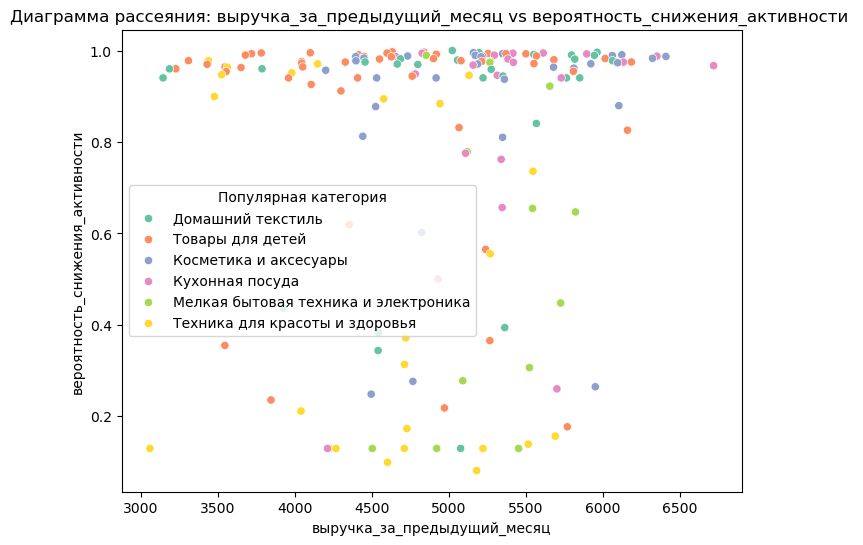

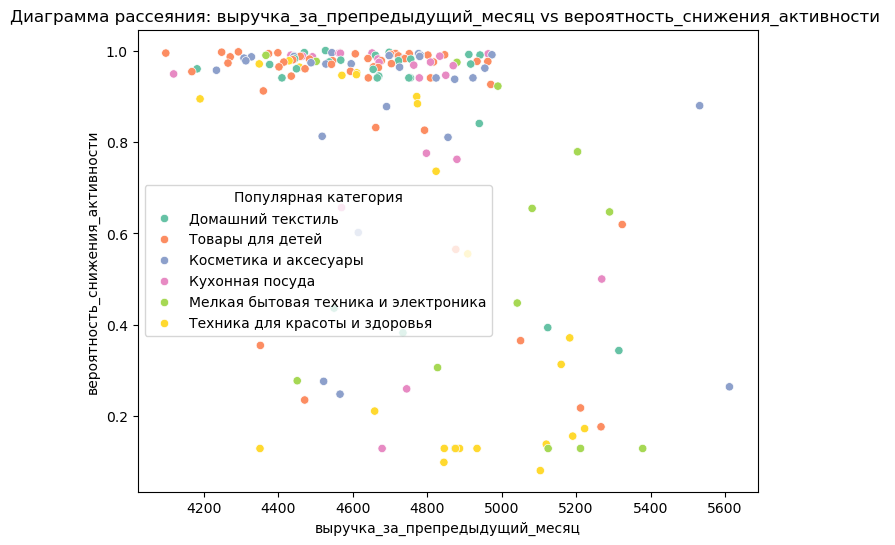

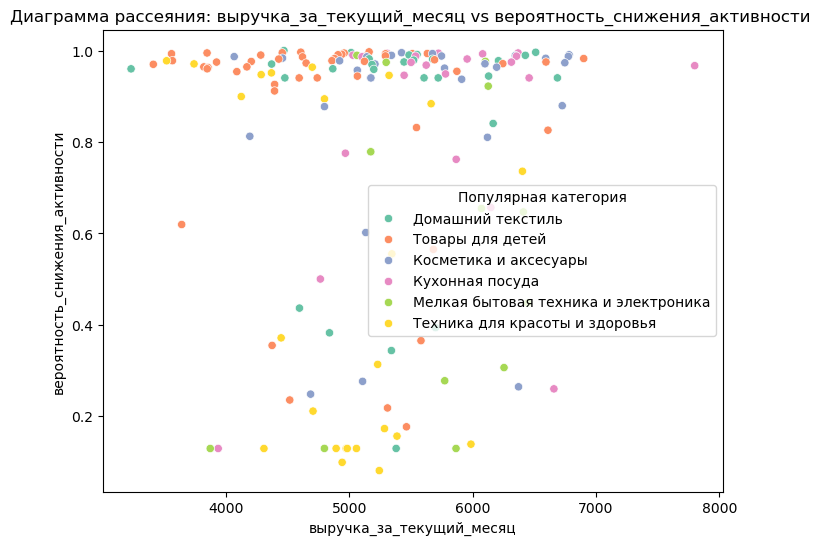

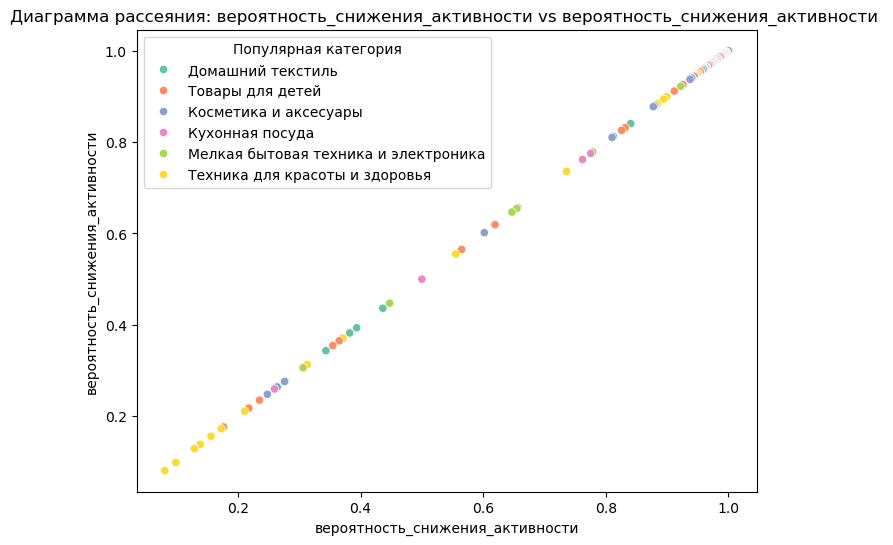

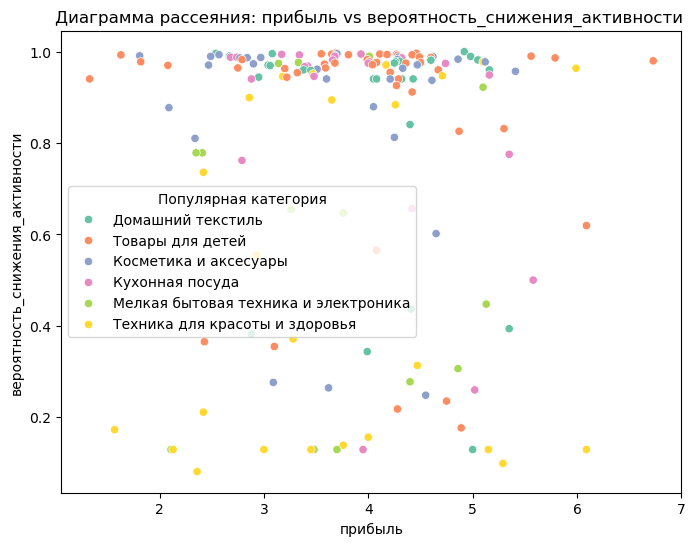

In [93]:
# список всех количественных признаков
quant_features = [col for col in segment.columns if col not in ['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']]

# цикл по каждому количественному признаку
for feature in quant_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=segment,
        x=feature,
        y='вероятность_снижения_активности',
        hue='популярная_категория',
        palette='Set2' 
    )
    plt.title(f'Диаграмма рассеяния: {feature} vs вероятность_снижения_активности ')
    plt.xlabel(feature)
    plt.ylabel('вероятность_снижения_активности')
    plt.legend(title='Популярная категория')
    plt.show()

Особенностей по графикам по категориям не выявлено

Посмотрим на процентное распределение приобретенных товаров по популярным категориям в выбранном сегменте.

In [94]:
segment[segment['покупательская_активность'] == 'Снизилась']['популярная_категория'].value_counts(normalize=True)*100

популярная_категория
Товары для детей                        32.824427
Косметика и аксесуары                   19.847328
Домашний текстиль                       18.320611
Кухонная посуда                         14.503817
Техника для красоты и здоровья           9.160305
Мелкая бытовая техника и электроника     5.343511
Name: proportion, dtype: float64

***Таким образом, около трети маркетинговых коммуникаций (персонифицированных предложений, акций) в отношении клиентов, находящихся в нашем выбранном сегменте, должны быть направлены по товарной группе "Товары для детей", 20% от всех акций - по группе "Косметика и аксесуары", 18% - по группе "Домашний текстиль", 14,5% - "Кухонная посуда", 9% - "Техника для красоты и здоровья", 5 % - "Мелкая бытовая техника и электроника".***

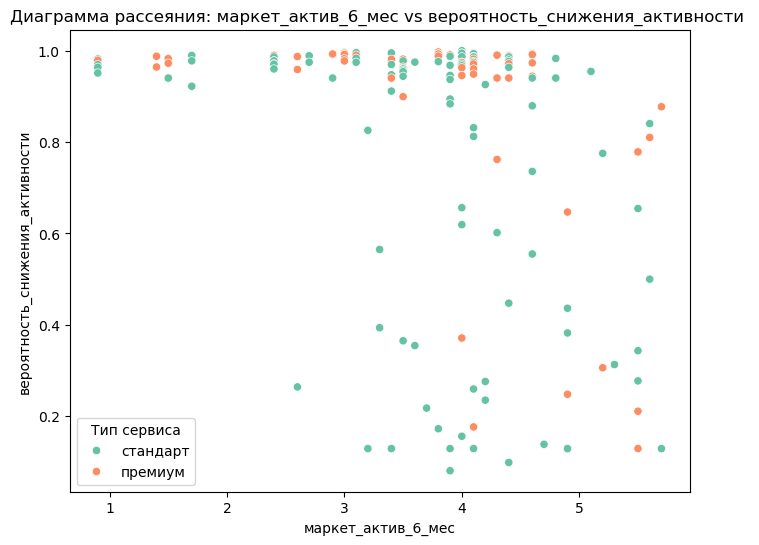

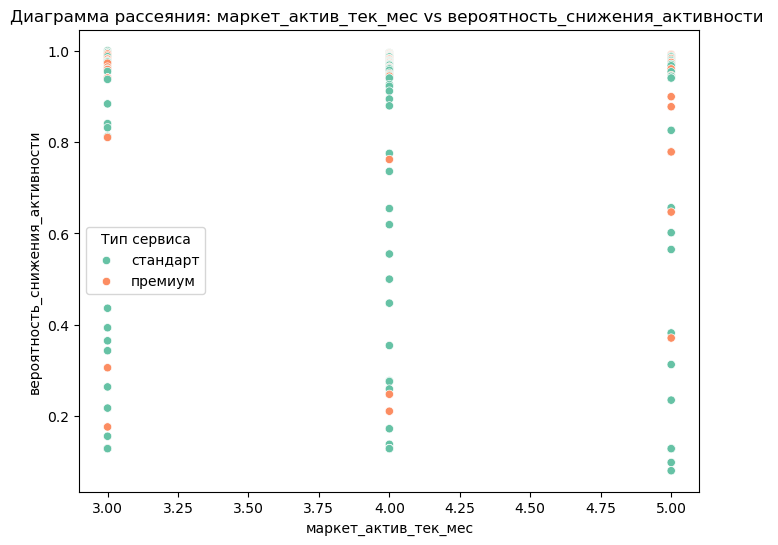

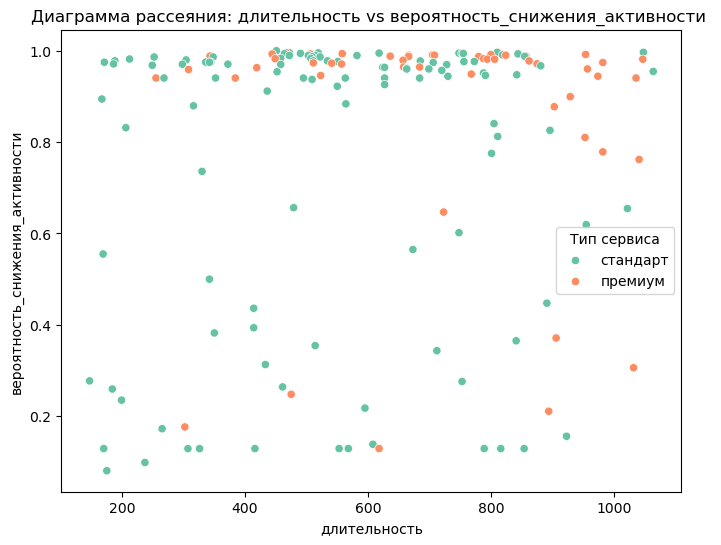

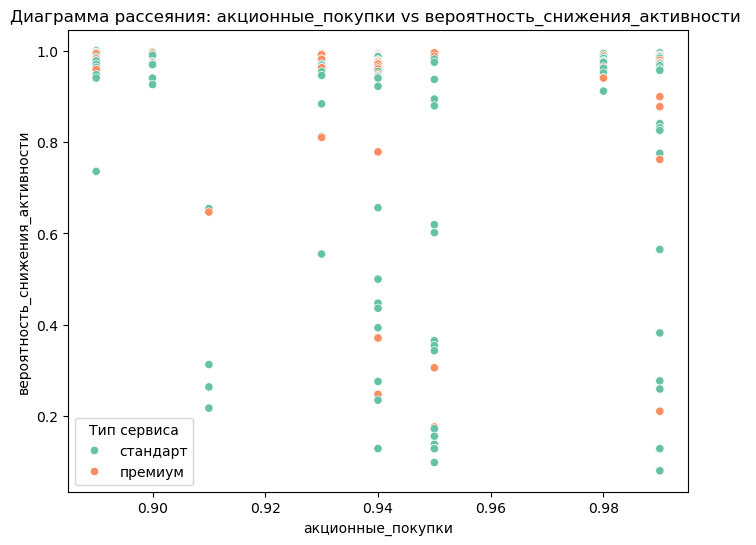

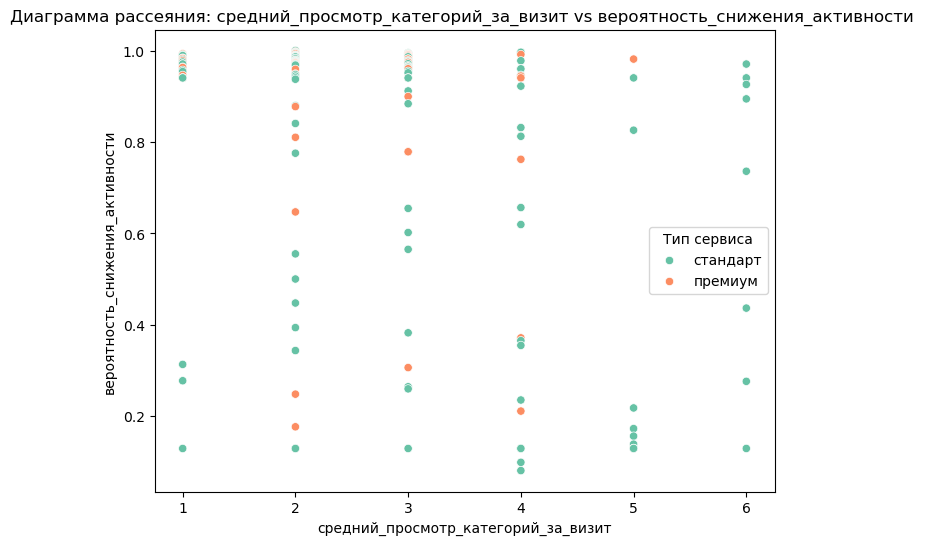

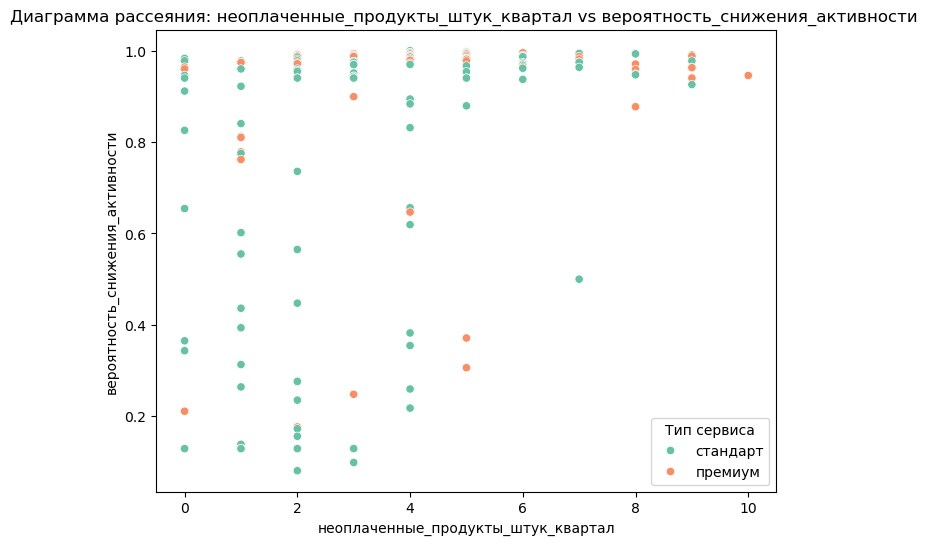

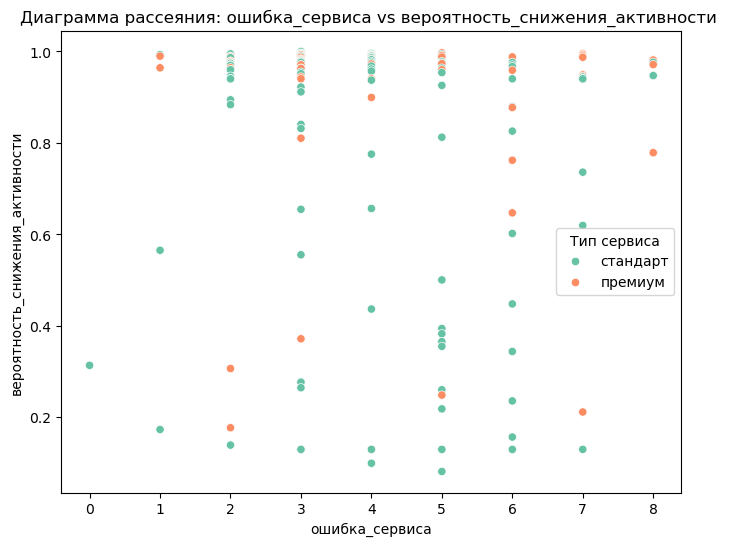

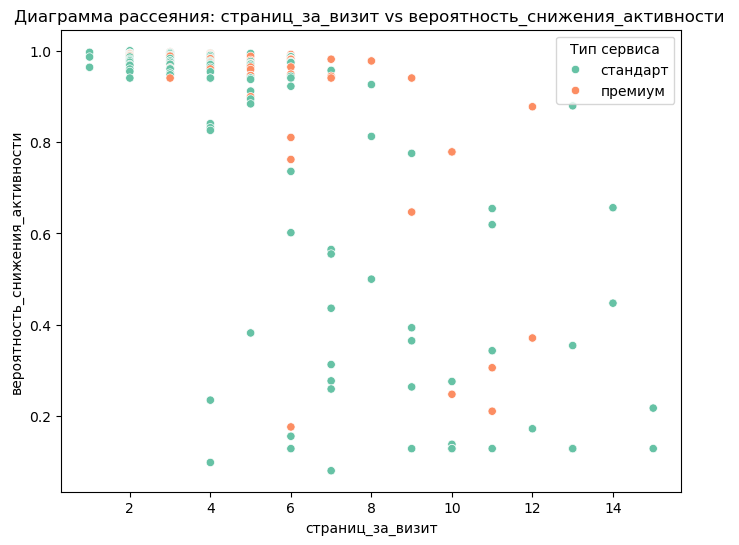

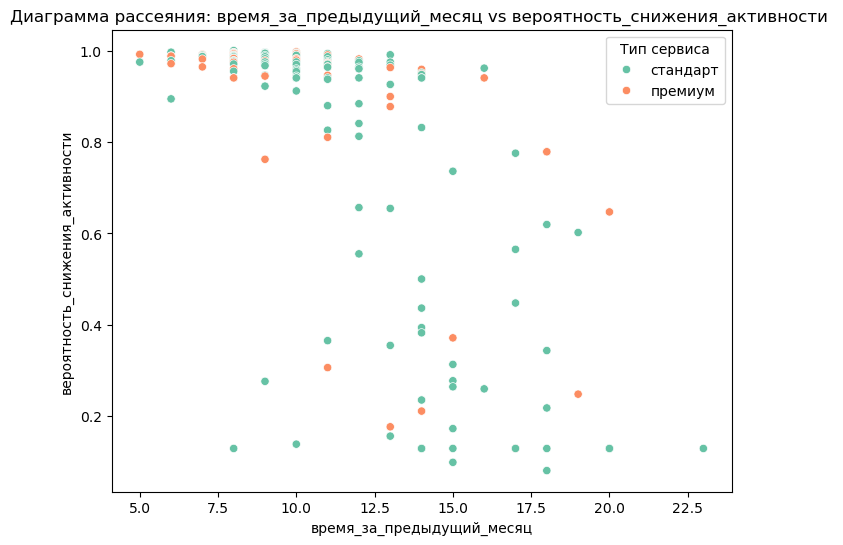

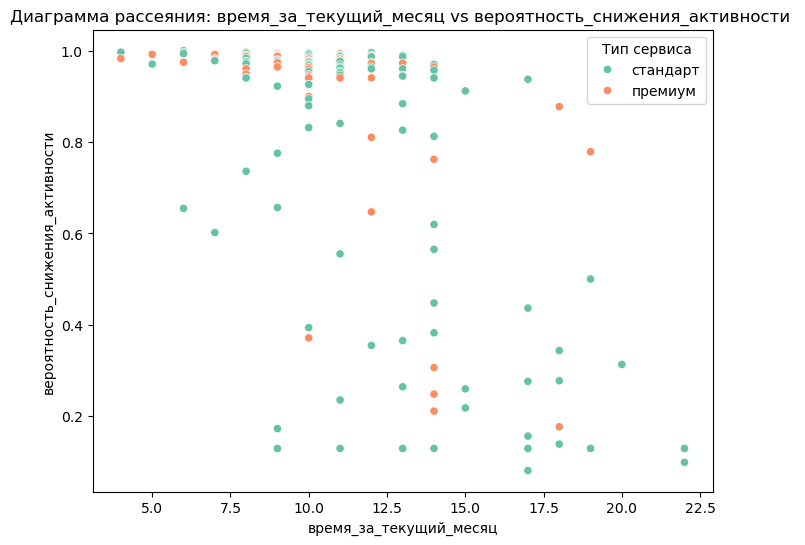

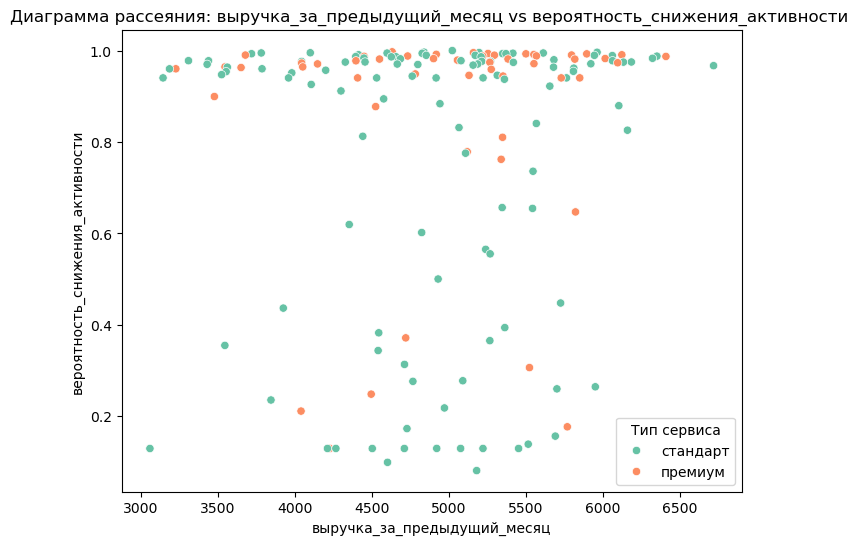

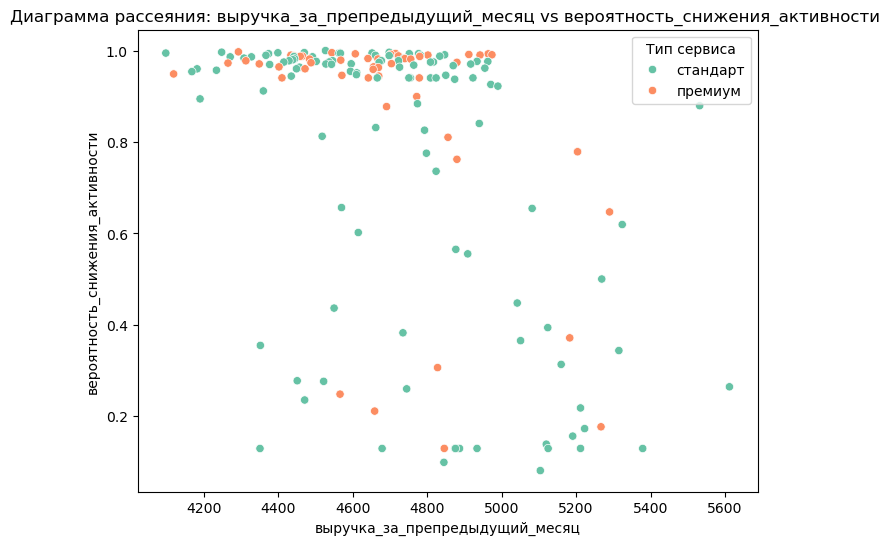

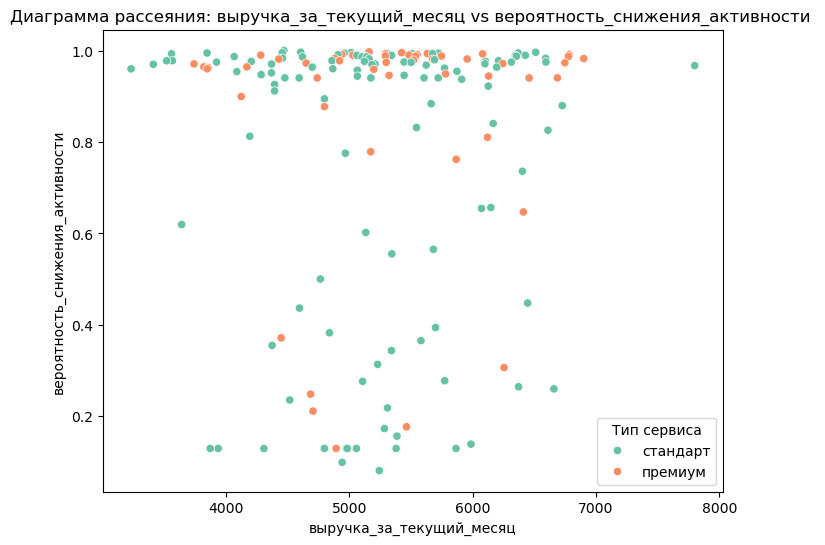

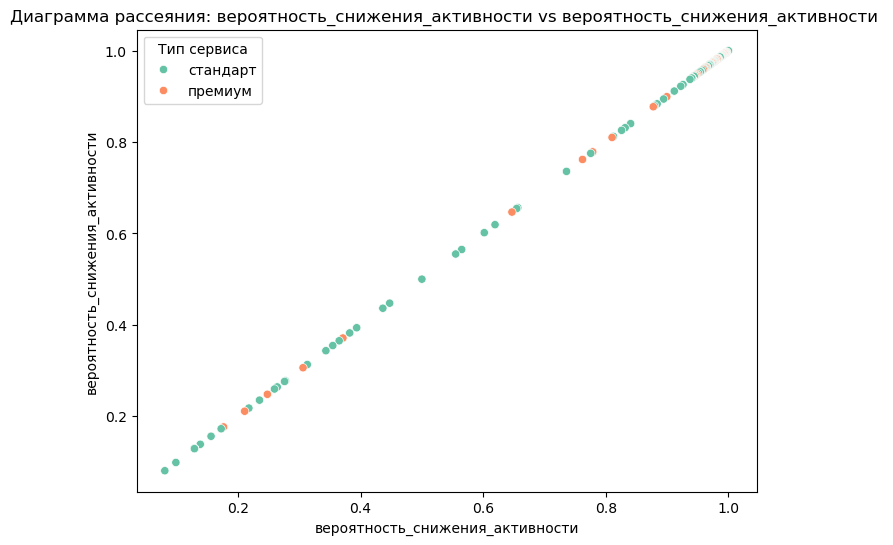

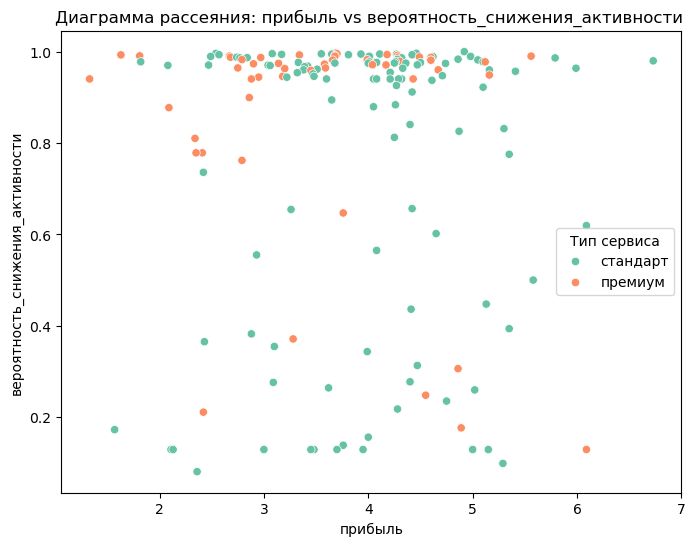

In [95]:
# список всех количественных признаков
quant_features = [col for col in segment.columns if col not in ['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']]

# цикл по каждому количественному признаку
for feature in quant_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=segment,
        x=feature,
        y='вероятность_снижения_активности',
        hue='тип_сервиса',
        palette='Set2' 
    )
    plt.title(f'Диаграмма рассеяния: {feature} vs вероятность_снижения_активности ')
    plt.xlabel(feature)
    plt.ylabel('вероятность_снижения_активности')
    plt.legend(title='Тип сервиса')
    plt.show()

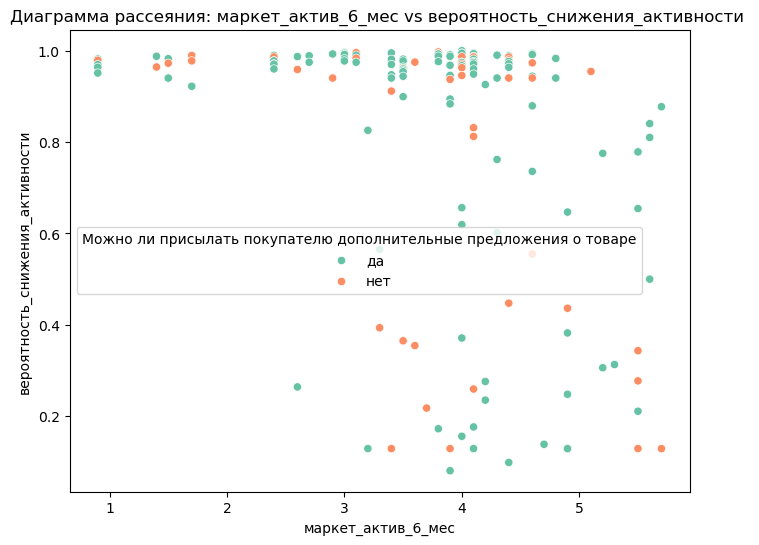

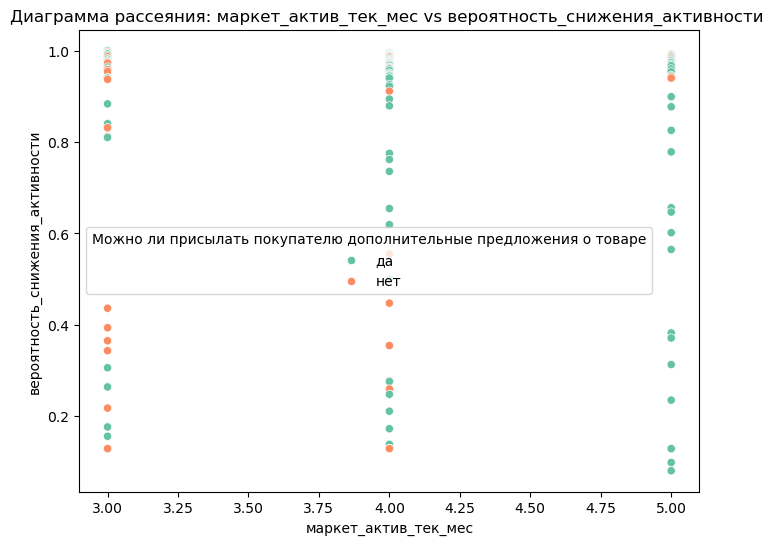

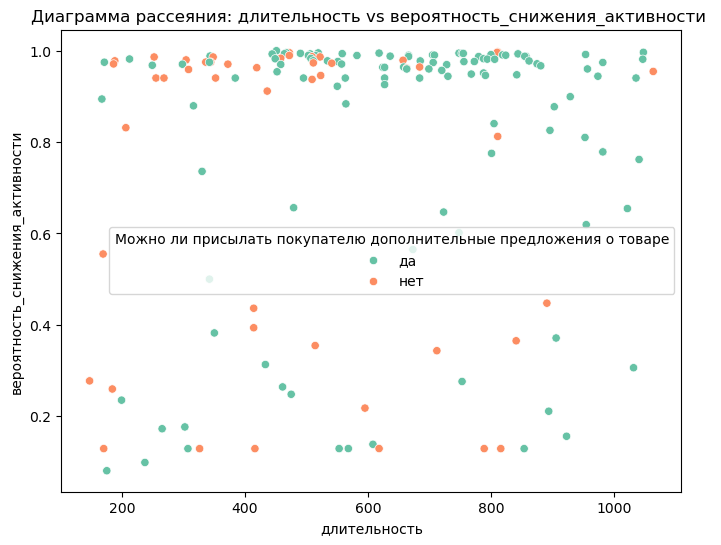

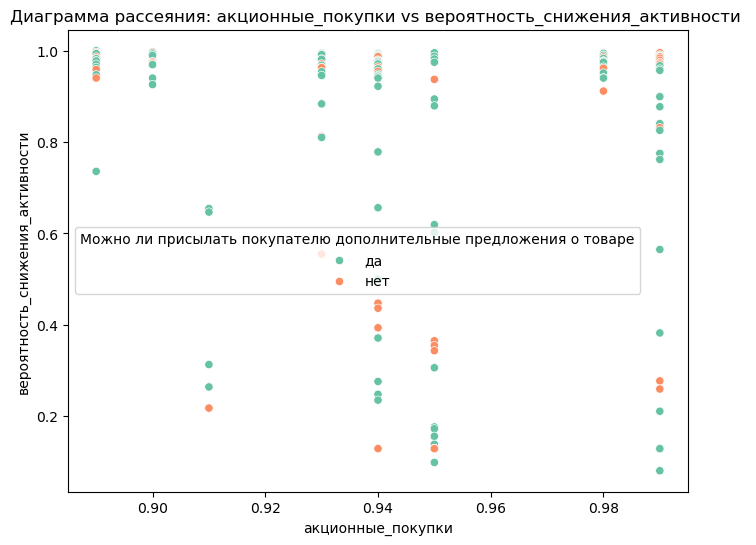

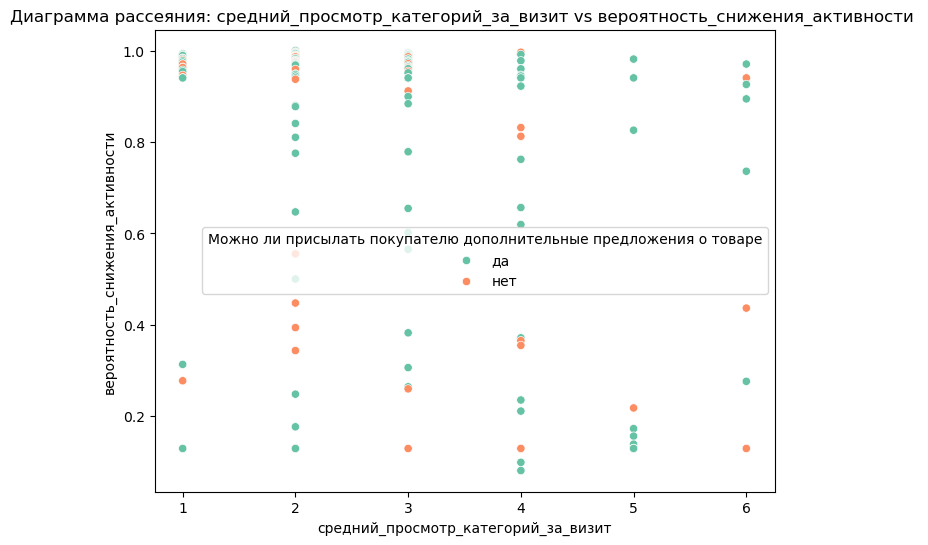

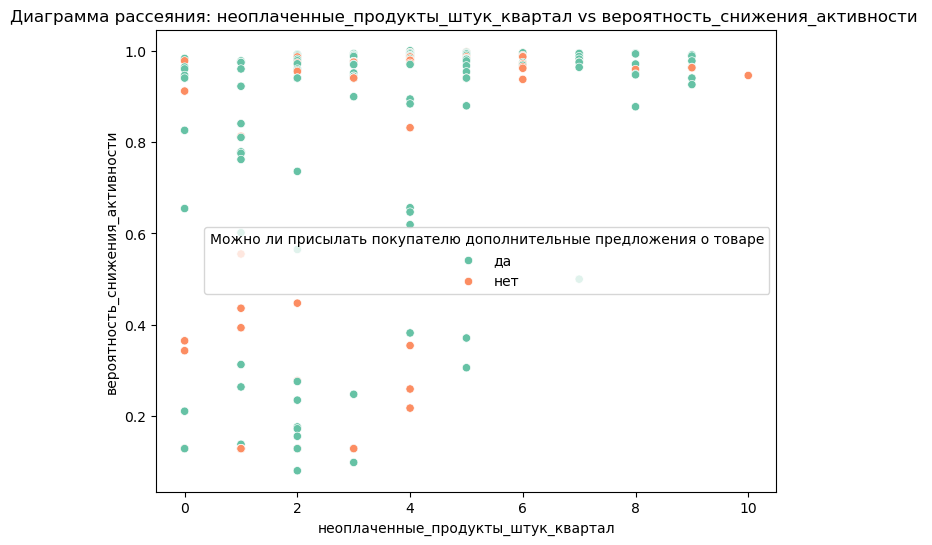

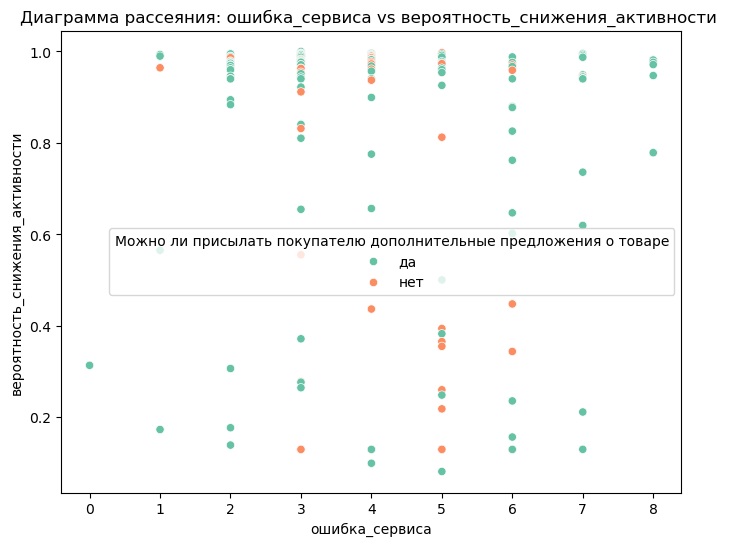

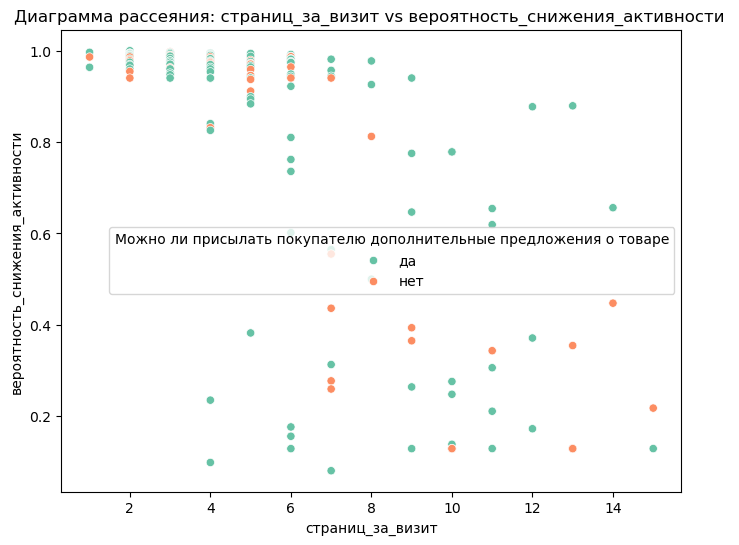

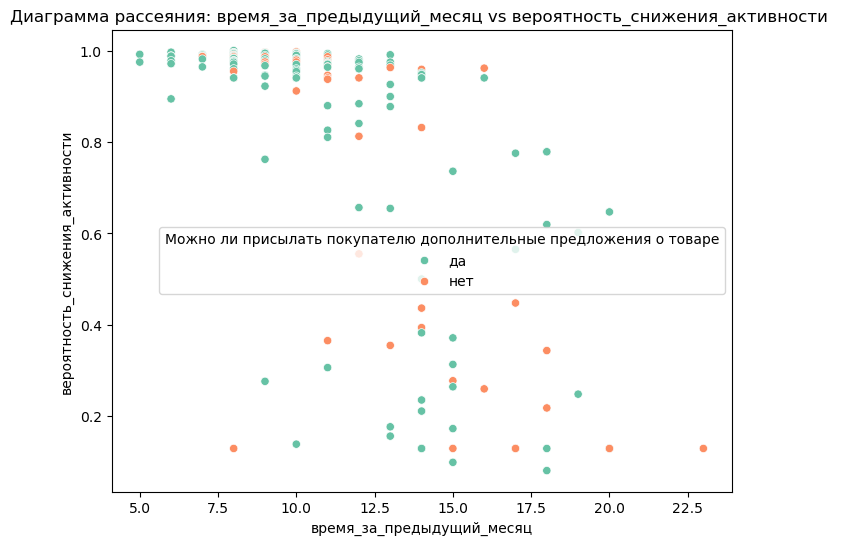

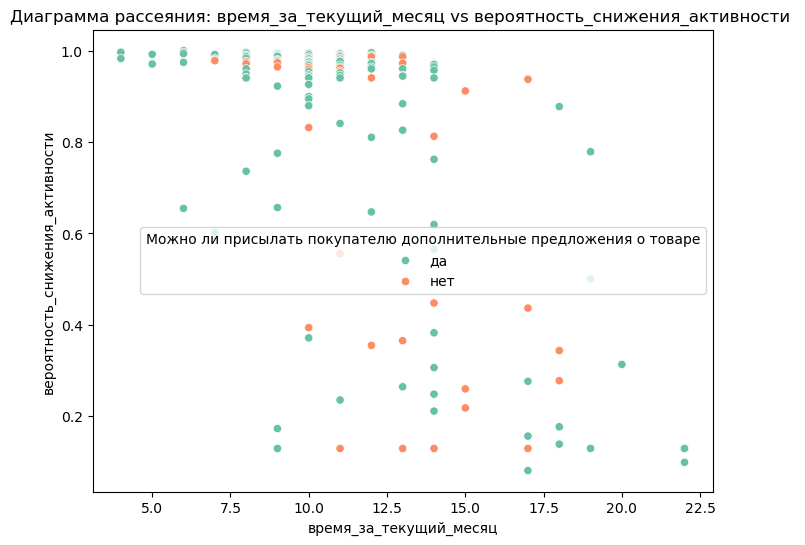

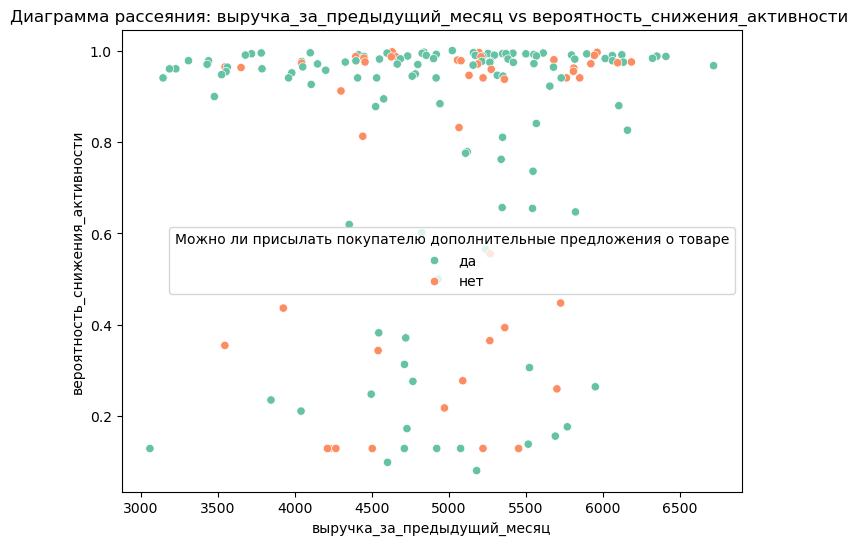

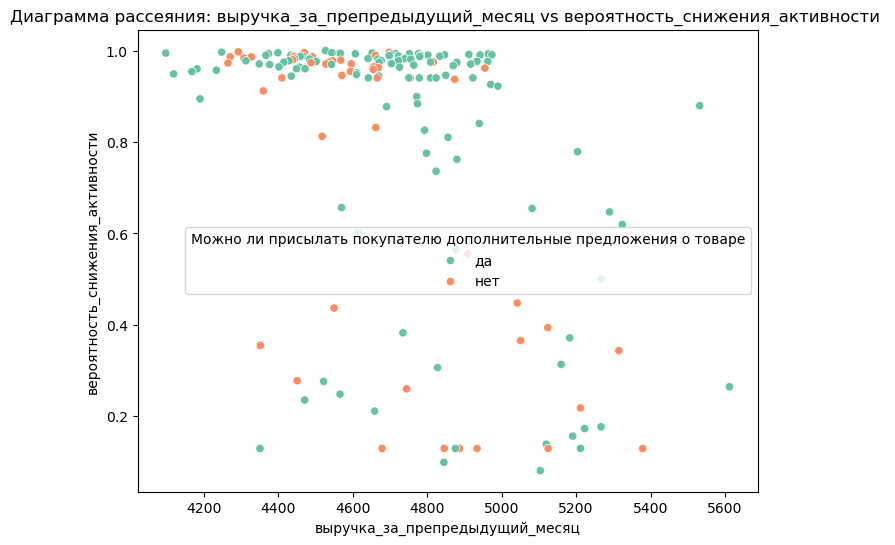

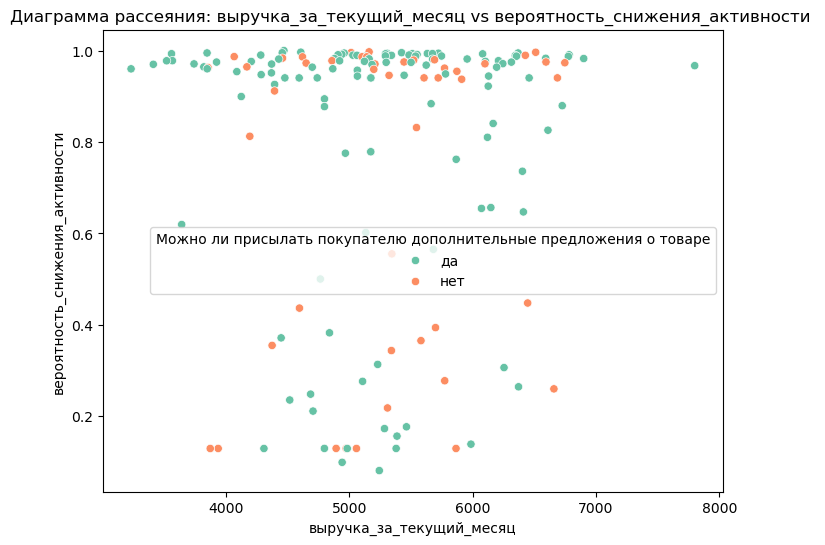

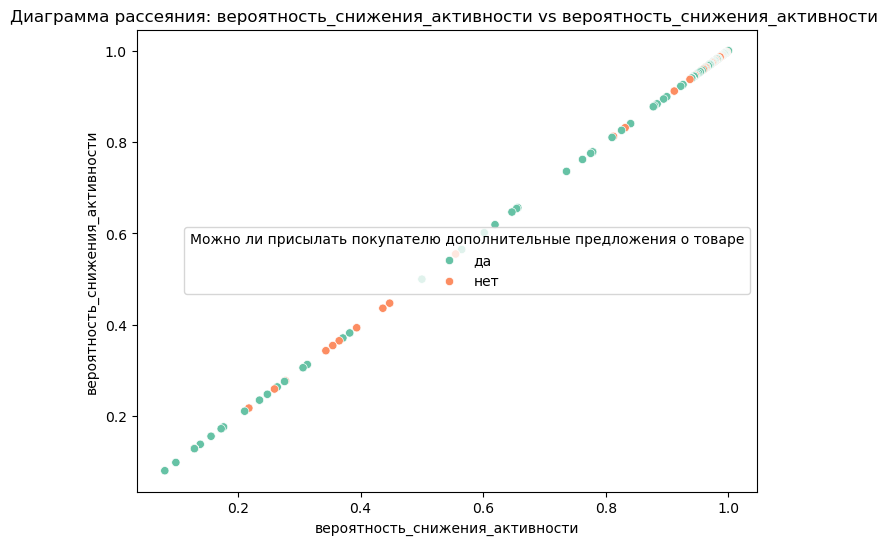

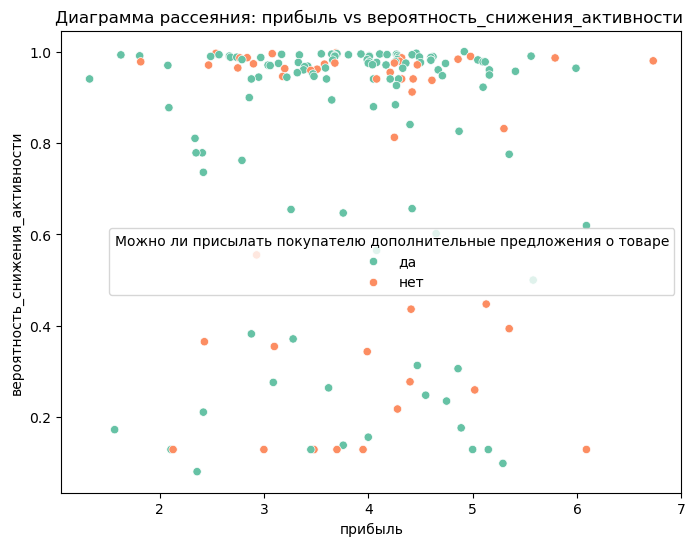

In [96]:
# список всех количественных признаков
quant_features = [col for col in segment.columns if col not in ['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']]

# цикл по каждому количественному признаку
for feature in quant_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=segment,
        x=feature,
        y='вероятность_снижения_активности',
        hue='разрешить_сообщать',
        palette='Set2' 
    )
    plt.title(f'Диаграмма рассеяния: {feature} vs вероятность_снижения_активности ')
    plt.xlabel(feature)
    plt.ylabel('вероятность_снижения_активности')
    plt.legend(title='Можно ли присылать покупателю дополнительные предложения о товаре')
    plt.show()

Особенностей по графикам по другим категориальным признакам не выявлено.

**Шаг 9. Итоговые выводы**

Поставленную задачу предстояло решить в два этапа:

- Разработать модель, которая предскажет вероятность снижения покупательской активности.
- Выделить сегмент покупателей, проанализировать его и предложить, как увеличить его покупательскую активность. Использовать данные моделирования, данные о прибыли покупателей и исходные данные (если понадобятся).

По решению:
- первоначально мы увидели, что исходные данные в датасетах соответствовали описанию;
-  пропуски в датасетах отсутствовали, полные дубликаты отсутствовали, мы привели к snake_case названия столбцов, устранили несколько технических ошибок в значениях столбцов;
- удалили выбросы по выручке;
- распределены нормально: выручка, прибыль, количество дней с момента регистрации пользователя на сайте;
- не распределены нормально: среднемесячное значение маркетинговых коммуникаций на покупателя за последние 6 месяцев, среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев, ;
- дискретные распределения: количеству маркетинговых коммуникаций в текущем месяце, среднему количеству просмотренных категорий за визит, число сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца, количество неоплаченных товаров, среднее количеству страниц за один визит на сайт за последние 3 месяца;
- объединили три датасета: данными о выручке c каждого покупателя,  данными о времени (в минутах), которое покупатель провёл на сайте в течение периода, данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении;
- провели корреляционный анализ и выявили, что:
       
       1. У пользователей, у которых снизилась покупательская активность, выручка за препредыдущий месяц меньше, чем у второй группы пользователей, за текущий и предыдущий месяцы - примерно на уровне.

        2. В среднем первая группа тратила практически в два раза меньше времени за визит, чем вторая группа, в предыдущем и текущем месяцах.

        3. В среднем количество страниц за визит у пользователей со снизившейся активностью составляет 4-5 страниц,у пользователей с прежним уровнем активности - 8-10 страниц

        4. На пользователей со снизившейся активностью все же приходится в среднем меньше маркетинговых коммуникаций

        5. У покупателей, у которых снизилась активность, количество неоплаченных продуктов в корзине больше, чем у пользователей, у которых активность на прежнем уровне

        6. В среднем люди, у уоторых снизилась покупательская активность, смотрят 2-3 категории за визит, а вторая группа пользователей - 3-5 категорий

        7. У основной массы пользователей обеих категорий доля ационных покупок в общем количестве покупоу не превышает 40%, при этом доля в сегменте пользователей, кто в основнмо покупает лишь товары по акциям (доля акционных покупок больше 85%), количество пользователй со снизившейся авктивнсотью в несколько раз выше количества пользователей с активностью на прежнем уровне.

        8. Наиболее популярная категория у обеих групп пользователей - товары для детей.
        
- для оценки качества модели выбрали оптимальную метрик, учитывающую баланс метрик, roc_auc;
- наиболее эффективной на валидационной выборке показала себя модель SVC;
- по графику SHAP наиболее важными признаками по всем наблюдениям являются 'страниц_за_визит', 'время_за_предыдущий_месяц', 'акционные_покупки', 'время_за_текущий_месяц', 'средний_просмотр_категорий_за_визит';

- выделили сегмент людей, чья покупательская активность снизилась, при этом они покупают по большей части лишь акцонные товары (доля акционных покупок в общем количестве покупок от 85% и более).

- в выделенном сегменте люди с высокой покупательской активностью просматривают больше страниц,  согласно SHAP самым важным признаком для классификации модели является как раз количество страниц за визит. При этом признак 'страниц_за_визит' кроме высокой связи с таргетом был связан умеренно (коэффициент 0.38) с признаком 'маркет_актив6мес'. Возможно, мы могли бы порекомендовать бизнесу увеличить среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя, при этом эффект в увеличении страниц за визит не будет быстрым ('маркет_актив_тек_месяц' вообще не связан с признаком 'страниц_за_визит');

- кроме того, в нашем сегменте люди с высокой покупательской активностью просматривают тратили больше времени как в текущем так и в предыдущем месяцах. Эти признаки также важны с точки зрения принятия моделью решения о классификации, и они также умеренно связаны с признаком 'маркет_актив6мес'.

***Итоговые рекомендации бизнесу по выбранному сегменту: около трети маркетинговых коммуникаций (персонифицированных предложений, акций) необходимо направлять в отношении клиентов, находящихся в нашем выбранном сегменте,по товарной группе "Товары для детей", 20% от всех акций - по группе "Косметика и аксесуары", 18% - по группе "Домашний текстиль", 14,5% - "Кухонная посуда", 9% - "Техника для красоты и здоровья", 5 % - "Мелкая бытовая техника и электроника".***